p.solve_surface_radiation_inplace(fix="alpha_c") calls a two-equation algebraic "radiation closure" that back-solves for an incoming shortwave value and an albedo so that the net radiation on each surface matches the available energy prescribed via $R_n-G$ and $G$ upwind and downwind of the transition.


 1) Define target net radiation for each patch
The routine first constructs the *target* net radiation for the fallow (upwind) and cultivated (downwind) surfaces:
$$
R_{n,f} = (R_n - G)_{\text{up}} + G = \texttt{p.RNmG\_up} + \texttt{p.G}
$$

$$
R_{n,c} = (R_n - G)_{\text{down}} + G = \texttt{p.RNmG\_down} + \texttt{p.G}.
$$


$$
\texttt{RNmG\_up} = \texttt{H\_f}, 
\qquad
\texttt{RNmG\_down} = \texttt{avail\_ratio}\,\texttt{H\_f}.
$$


 2) Assume a simple net-radiation model for each surface

For each surface type, the code uses
$$
R_{n,s} = SW\,(1-\alpha_s)
\;+\; \varepsilon_a \sigma T_a^4 \;-\; \varepsilon_s \sigma T_s^4,
$$

where 
- $SW$ is incoming shortwave
- $\alpha_s$ is the surface albedo
- $\varepsilon_a$ is an effective atmospheric emissivity, 
- $\varepsilon_s$ is the surface emissivity, and 
- $\sigma$ is the Stefan--Boltzmann constant. 

Temperatures are converted to Kelvin internally:
$$
T_K = T_{\mathrm{C}} + 273.15.
$$

Thus the two balances are
$$
SW(1-\alpha_f) + \varepsilon_a\sigma T_a^4 - \varepsilon_f\sigma T_{sf}^4 = R_{n,f},
$$

$$
SW(1-\alpha_c) + \varepsilon_a\sigma T_a^4 - \varepsilon_c\sigma T_{sc}^4 = R_{n,c}.
$$

 3)  With `fix="alpha_c"`, $\alpha_c$ is treated as known (held at $\texttt{p.alpha\_c}$), and the unknowns are

$SW \quad \text{and} \quad \alpha_f$ 

Sympy solves the resulting $2\times 2$ system (linear in the unknowns).

Equivalently, the solution can be written explicitly as
$$SW = \frac{R_{n,c} - \varepsilon_a\sigma T_a^4 + \varepsilon_c\sigma T_{sc}^4}{1-\alpha_c}$$

$$\alpha_f = 1 - \frac{R_{n,f} - \varepsilon_a\sigma T_a^4 + \varepsilon_f\sigma T_{sf}^4}{SW}.
$$

4. After solving, the routine **updates the parameter object**:
- $\texttt{p.SW\_in} \leftarrow SW$,
- $\texttt{p.alpha\_f} \leftarrow \alpha_f$ (clipped to $[0,1]$).


- Where are `alpha_f` and `alpha_c` actually used in the rest of the code? 


### Including relative humidity

Convert vapor concentration $Q$ (in $\mathrm{g\,m^{-3}}$) to vapor pressure $e$ (Pa) using the ideal-gas law for water vapor:
$$
e = \rho_v R_v T,
\qquad
\rho_v = \frac{Q}{1000},
$$

where 
- $\rho_v$ is water vapor density in $\mathrm{kg\,m^{-3}}$, 
- $R_v$ is the specific gas constant for water vapor, and
- $T$ is absolute temperature (K).

Then compute relative humidity as
$$
RH = 100\,\frac{e}{e_s(T)},
$$

where $e_s(T)$ is the saturation vapor pressure at temperature $T$.

In [ ]:
%%time
import numpy as np
import matplotlib.pyplot as plt
import sys
import math
import pandas as pd
import numpy as np



CPU times: user 13 µs, sys: 27 µs, total: 40 µs
Wall time: 216 µs


In [10]:
import sys
sys.path.insert(0, "/Users/octaviacrompton/Projects/suttons_problem/src")

# Project imports
from sutton import (
    Params,
    thomas,
    our_central_difference,
    integrate_T_implicit,
    integrate_H2O_implicit,
    stability,
    saturation_vapor_pressure,
    vapor_concentration_RH,
)


In [ ]:
pwd

In [11]:
def get_lm(k, h, z, option = 'kz'):
    """
    mixing length options
    """
    d = 2/3*h
    
    if option != 'kz':
        zo = 0.005
        lm = k*(z + zo)
    else:
        a = 1
        lm = k*z   
        lm[z < a*(h - d)] = k*a*h/3 
    return lm


### Boundary conditions from Rao et al (1974)

In [12]:
sigma_sb = 5.670374419e-8  # W m^-2 K^-4

cp_air  = 1005.0     # J kg^-1 K^-1
rho_air = 1.20       # kg m^-3

Lv      = 2.43e6     # J kg^-1
Lv_g    = 2430.0     # J g^-1  (~30 °C)

# mcal_to_J = 4.184e-3  # 1 mcal = 4.184e-3 J
# cm2_to_m2 = 1e-4      # 1 cm² = 1e-4 m²
# H01_mcal_cm2_s = 8.5  # Given value in mcal/cm²/s

# Convert to SI units (W/m²)
Q_f = 6.34 # g m3

RH_c = 60 # relative humidity
ustar_f = 0.14


In [13]:
# If you don't already have this defined somewhere:
sigma_sb = 5.670374419e-8  # W m^-2 K^-4

def print_radiation_budget(p: "Params", sigma: float = sigma_sb, digits: int = 2) -> dict:
    """
    Print (and return) the upwind (f) and downwind (c) radiation-budget terms
    consistent with p.solve_surface_radiation_inplace().

    Uses:
      Rn = SW*(1-alpha) + eps_a*sigma*Ta^4 - eps_s*sigma*Ts^4
      target Rn_f = RNmG_up + G
      target Rn_c = RNmG_down + G
    """
    def K(Tc): return Tc + 273.15

    SW   = float(p.SW_in)
    TaK  = K(float(p.T_a))
    TsfK = K(float(p.T_sf))
    TscK = K(float(p.T_sc))

    # Common atmospheric longwave down term in this simplified closure
    LW_down = float(p.epsilon_a) * sigma * TaK**4

    # --- Upwind / fallow (f) ---
    SWabs_f = SW * (1.0 - float(p.alpha_f))
    LWup_f  = float(p.epsilon_f) * sigma * TsfK**4
    Rn_f    = SWabs_f + LW_down - LWup_f
    RNmG_f  = Rn_f - float(p.G)
    Rn_f_target = float(p.RNmG_up) + float(p.G)

    # --- Downwind / cultivated (c) ---
    SWabs_c = SW * (1.0 - float(p.alpha_c))
    LWup_c  = float(p.epsilon_c) * sigma * TscK**4
    Rn_c    = SWabs_c + LW_down - LWup_c
    RNmG_c  = Rn_c - float(p.G)
    Rn_c_target = float(p.RNmG_down) + float(p.G)

    out = {
        "common": {
            "SW_in": SW,
            "Ta_K": TaK,
            "LW_down": LW_down,
            "G": float(p.G),
            "RNmG_up": float(p.RNmG_up),
            "RNmG_down": float(p.RNmG_down),
        },
        "upwind_f": {
            "alpha_f": float(p.alpha_f),
            "epsilon_f": float(p.epsilon_f),
            "Ts_K": TsfK,
            "SW_absorbed": SWabs_f,
            "LW_up": LWup_f,
            "Rn": Rn_f,
            "Rn_minus_G": RNmG_f,
            "Rn_target": Rn_f_target,
            "Rn_mismatch": Rn_f - Rn_f_target,
        },
        "downwind_c": {
            "alpha_c": float(p.alpha_c),
            "epsilon_c": float(p.epsilon_c),
            "Ts_K": TscK,
            "SW_absorbed": SWabs_c,
            "LW_up": LWup_c,
            "Rn": Rn_c,
            "Rn_minus_G": RNmG_c,
            "Rn_target": Rn_c_target,
            "Rn_mismatch": Rn_c - Rn_c_target,
        },
    }

    r = lambda x: float(np.round(x, digits))

    print("=== Radiation budget (closure-consistent) ===")
    print(f"SW_in = {r(SW)} W m^-2")
    print(f"Ta = {r(p.T_a)} °C  ({r(TaK)} K)")
    print(f"eps_a = {p.epsilon_a}  => LW_down = eps_a*sigma*Ta^4 = {r(LW_down)} W m^-2")
    print(f"G = {r(p.G)} W m^-2")
    print(f"Targets: RNmG_up = {r(p.RNmG_up)} , RNmG_down = {r(p.RNmG_down)}  (W m^-2)")
    print()

    print("--- Upwind (f) ---")
    print(f"alpha_f={p.alpha_f}, eps_f={p.epsilon_f}, Ts_f={r(p.T_sf)} °C ({r(TsfK)} K)")
    print(f"  SW_abs = SW*(1-alpha_f) = {r(SWabs_f)}")
    print(f"  LW_up  = eps_f*sigma*Ts^4 = {r(LWup_f)}")
    print(f"  Rn     = {r(Rn_f)}   |  Rn-G = {r(RNmG_f)}")
    print(f"  target Rn = RNmG_up + G = {r(Rn_f_target)}   | mismatch = {r(Rn_f - Rn_f_target)}")
    print()

    print("--- Downwind (c) ---")
    print(f"alpha_c={p.alpha_c}, eps_c={p.epsilon_c}, Ts_c={r(p.T_sc)} °C ({r(TscK)} K)")
    print(f"  SW_abs = SW*(1-alpha_c) = {r(SWabs_c)}")
    print(f"  LW_up  = eps_c*sigma*Ts^4 = {r(LWup_c)}")
    print(f"  Rn     = {r(Rn_c)}   |  Rn-G = {r(RNmG_c)}")
    print(f"  target Rn = RNmG_down + G = {r(Rn_c_target)}   | mismatch = {r(Rn_c - Rn_c_target)}")

    return out


In [14]:
import numpy as np

Rv = 461.5  # J kg^-1 K^-1 (water vapor gas constant)

def print_surface_moisture_check(p: "Params", digits: int = 3) -> dict:
    """
    Print (and return) surface moisture consistency checks at the upwind (f) and
    downwind (c) surfaces using your conventions:

      T in °C
      Q in g m^-3 (absolute humidity / vapor concentration)
      RH in %

    It reports:
      - RH implied by (T, Q)
      - Q implied by (T, RH) (if RH is available)
      - mismatches vs stored RH/Q
      - saturation vapor concentration Q_sat(T) (g m^-3)
    """
    def K(Tc): return float(Tc) + 273.15

    # --- helpers (standalone so this works even if you refactor Params later) ---
    def RH_from_Q(Tc: float, Q_gm3: float) -> float:
        Tk = K(Tc)
        rho_v = float(Q_gm3) / 1000.0                # kg m^-3
        e = rho_v * Rv * Tk                          # Pa
        es = saturation_vapor_pressure(Tk)            # Pa
        return 100.0 * (e / es)

    def Q_from_RH(Tc: float, RH_pct: float) -> float:
        return float(vapor_concentration_RH(float(Tc), float(RH_pct)))  # g m^-3

    def r(x):
        if x is None:
            return None
        return float(np.round(float(x), digits))

    # pull stored values (RH_f may not exist yet)
    RHc_stored = getattr(p, "RH_c", None)
    RHf_stored = getattr(p, "RH_f", None)

    Tc, Tf = float(p.T_sc), float(p.T_sf)
    Qc, Qf = float(p.Q_c), float(p.Q_f)

    # implied from (T, Q)
    RHc_fromQ = RH_from_Q(Tc, Qc)
    RHf_fromQ = RH_from_Q(Tf, Qf)

    # implied from (T, RH) if RH exists
    Qc_fromRH = Q_from_RH(Tc, RHc_stored) if RHc_stored is not None else None
    Qf_fromRH = Q_from_RH(Tf, RHf_stored) if RHf_stored is not None else None

    # saturation vapor concentration at each surface
    Qsat_c = Q_from_RH(Tc, 100.0)
    Qsat_f = Q_from_RH(Tf, 100.0)

    out = {
        "downwind_c": {
            "T_C": Tc, "T_K": K(Tc),
            "Q_gm3": Qc,
            "RH_stored_pct": RHc_stored,
            "RH_from_Q_pct": RHc_fromQ,
            "RH_mismatch_pct": (RHc_fromQ - float(RHc_stored)) if RHc_stored is not None else None,
            "Q_from_RH_gm3": Qc_fromRH,
            "Q_mismatch_gm3": (Qc_fromRH - Qc) if Qc_fromRH is not None else None,
            "Q_sat_gm3": Qsat_c,
        },
        "upwind_f": {
            "T_C": Tf, "T_K": K(Tf),
            "Q_gm3": Qf,
            "RH_stored_pct": RHf_stored,
            "RH_from_Q_pct": RHf_fromQ,
            "RH_mismatch_pct": (RHf_fromQ - float(RHf_stored)) if RHf_stored is not None else None,
            "Q_from_RH_gm3": Qf_fromRH,
            "Q_mismatch_gm3": (Qf_fromRH - Qf) if Qf_fromRH is not None else None,
            "Q_sat_gm3": Qsat_f,
        }
    }

    print("=== Surface moisture check (T, Q, RH) ===")
    print("Conventions: T in °C, Q in g m^-3, RH in %")
    print()

    # --- downwind (c) ---
    c = out["downwind_c"]
    print("--- Downwind surface (c) ---")
    print(f"T_sc = {r(c['T_C'])} °C  ({r(c['T_K'])} K)")
    print(f"Q_c  = {r(c['Q_gm3'])} g m^-3   | Q_sat(T_sc) = {r(c['Q_sat_gm3'])} g m^-3")
    print(f"RH implied by (T_sc, Q_c): {r(c['RH_from_Q_pct'])} %")
    if c["RH_stored_pct"] is not None:
        print(f"RH stored: {r(c['RH_stored_pct'])} %   | mismatch = {r(c['RH_mismatch_pct'])} %")
        print(f"Q implied by (T_sc, RH_stored): {r(c['Q_from_RH_gm3'])} g m^-3"
              f"   | mismatch vs Q_c = {r(c['Q_mismatch_gm3'])} g m^-3")
    else:
        print("RH stored: None (only reporting RH implied by Q)")
    print()

    # --- upwind (f) ---
    f = out["upwind_f"]
    print("--- Upwind surface (f) ---")
    print(f"T_sf = {r(f['T_C'])} °C  ({r(f['T_K'])} K)")
    print(f"Q_f  = {r(f['Q_gm3'])} g m^-3   | Q_sat(T_sf) = {r(f['Q_sat_gm3'])} g m^-3")
    print(f"RH implied by (T_sf, Q_f): {r(f['RH_from_Q_pct'])} %")
    if f["RH_stored_pct"] is not None:
        print(f"RH stored: {r(f['RH_stored_pct'])} %   | mismatch = {r(f['RH_mismatch_pct'])} %")
        print(f"Q implied by (T_sf, RH_stored): {r(f['Q_from_RH_gm3'])} g m^-3"
              f"   | mismatch vs Q_f = {r(f['Q_mismatch_gm3'])} g m^-3")
    else:
        print("RH stored: None (only reporting RH implied by Q)")

    return out


In [15]:
Qa_default = 6
Rv = 461.5  # J kg^-1 K^-1 (water vapor gas constant)
from dataclasses import dataclass, asdict
from typing import Optional
import numpy as np
from functools import cached_property
from sutton import saturation_vapor_pressure, vapor_concentration_RH
import sympy as sp

from dataclasses import fields

    
@dataclass
class Params:
    # --- core physics/numerics  ---
    k: float = 0.4
    zom_f: float = 0.0005            # m (wet/downwind momentum roughness)
    zom_c: float = 0.0005            # m (dry/upwind momentum roughness)

    # canopy & displacement inputs (per patch)
    # (If None → derive from z0m via alpha_m = 0.1 , disp_frac)
    h_f_opt: Optional[float] = None
    h_c_opt: Optional[float] = None
        
    d_f_opt: Optional[float] = None
    d_c_opt: Optional[float] = None
                
    alpha_m: float = 0.10          # z0m ≈ alpha_m * h
    disp_frac: float = 0.67        # d ≈ disp_frac * h
    
    G : float = 0
    # domain/grid
    Lx: float = 100.0               # m
    Hmax: float = 10.0              # m
    dz: float = 0.1                 # m
    dx: float = 1                   # m
    xmin: float = 0.0               # m

    # friction velocities (optional; None ⇒ compute later or via resolve_ustars)
    ustar_f: Optional[float] = 0.15
    ustar_c: Optional[float] = 0.15

    # block pattern
    fallow_fraction: float = 0.5
    fallow_length: float = 1000.0  # m

    # temperatures in °C; RH in %
    T_sc: float = 28.5
    T_sf: float = 40.0
    T_a:  float = 30.0


    # ---- Surface moisture (choose ONE per surface at init) ----
    # Provide either RH_* (%) or Q_* (g m^-3). If neither is provided, defaults are used.
    RH_c: Optional[float] = None
    RH_f: Optional[float] = None
    Q_c:  Optional[float] = None   # g m^-3
    Q_f:  Optional[float] = None   # g m^-3
        
    Q_a: float = Qa_default
    tie_Qa_to_Qf: bool = False   # <-- NEW        

    # radiation inputs 
    SW_in: float = 400.0
    epsilon_f: float = 0.90
    epsilon_c: float = 0.95
    epsilon_a: float = 0.80
    alpha_c: float = 0.22
    alpha_f: float = 0.22
        
    lm_option: str | None = "kz"
    lm_zshift: float = 0.005   # m, additive shift in lm = k * (z + lm_zshift)

    # reference wind for u* inference (if you compute from log law)
    U_ref: float = 3.76            # m s^-1 at z_ref_wind
    z_ref_wind: float = 4.0        # m

    # Upstream/base flux: Rao base case uses (RN-G)_up = H_f
    H_f: float = 355.64                # ≈ 356 W m^-2
    LE_f: float = 0.0                  # upstream LE 
    
    # avail_ratio 1: downstream available energy & partition 
    avail_ratio: float = 1             # (RN-G)_down / (RN-G)_up, dimensionless
    le_factor: float = 1.0             # 0..1: downstream LE_c = le_factor * avail_ratio

        
    # ----------------- helpers & grids -----------------
    @staticmethod
    def _K(Tc: float) -> float:
        return Tc + 273.15

    # derived canopy height & displacement (per patch)
    @cached_property
    def h_f(self) -> float:
        if self.h_f_opt is not None: return float(self.h_f_opt)
        if self.d_f_opt is not None: return float(self.d_f_opt) / self.disp_frac
        return float(self.zom_f) / self.alpha_m

    @cached_property
    def h_c(self) -> float:
        if self.h_c_opt is not None: return float(self.h_c_opt)
        if self.d_c_opt is not None: return float(self.d_c_opt) / self.disp_frac
        return float(self.zom_c) / self.alpha_m

    @cached_property
    def d_f(self) -> float:
        if self.d_f_opt is not None: return float(self.d_f_opt)
        if self.h_f_opt is not None: return self.disp_frac * float(self.h_f_opt)
        return self.disp_frac * (float(self.zom_f) / self.alpha_m)

    @cached_property
    def d_c(self) -> float:
        if self.d_c_opt is not None: return float(self.d_c_opt)
        if self.h_c_opt is not None: return self.disp_frac * float(self.h_c_opt)
        return self.disp_frac * (float(self.zom_c) / self.alpha_m)

    #  zmin respects z > z0
    # z is above the zero plane displacement
    @cached_property
    def zmin(self) -> float:
        thresh_f = self.zom_f
        thresh_c = self.zom_c
        return max(thresh_f, thresh_c)   # conservative global lower bound
        

    @cached_property
    def z(self) -> np.ndarray:
        return np.arange(self.zmin, self.Hmax,  self.dz)

    @cached_property
    def x(self) -> np.ndarray:
        return np.arange(self.xmin, self.Lx + self.dx, self.dx)

    @property
    def nz(self) -> int: return len(self.z)

    @property
    def nx(self) -> int: return len(self.x)

    # u* optional compute (unchanged)
    def resolve_ustars(self):
        if self.ustar_f is None:
            assert self.z_ref_wind > self.zom_f > 0
            self.ustar_f = self.k * self.U_ref / np.log(self.z_ref_wind / self.zom_f)
        if self.ustar_c is None:
            assert self.z_ref_wind > self.zom_c > 0
            self.ustar_c = self.k * self.U_ref / np.log(self.z_ref_wind / self.zom_c)
        return self

    # block sizes (fixed ternary line break)
    @cached_property
    def fallow_size(self) -> int:
        return int(self.fallow_length / self.dx)

    @cached_property
    def field_size(self) -> int:
        return (
            int(self.fallow_size * 
                (1 - self.fallow_fraction) / self.fallow_fraction)
            if self.fallow_fraction > 0 else 0
        )
    
    @cached_property
    def lm(self):
        d = 2/3 * self.h_c
        z = self.z
        k = self.k
        h = self.h_c

        if self.lm_option == 'kz':
            # tunable vertical shift instead of hard-coded 0.005
            lm = k * (z + self.lm_zshift)
        else:
            a = 1
            lm = k * z
            lm[z < a * (h - d)] = k * a * h / 3
        return lm


    # Saturation vapor pressure over liquid water (Pa) via Clausius–Clapeyron
    @cached_property
    def es_c(self) -> float:
        return saturation_vapor_pressure(self._K(self.T_sc))

    @cached_property
    def es_f(self) -> float:
        return saturation_vapor_pressure(self._K(self.T_sf))


    # energy partition
    #  upstream available energy  
    @property
    def RNmG_up(self) -> float:
        return self.H_f + self.LE_f

    @property
    def RNmG_down(self) -> float:
        """Downstream available energy = 
        avail_ratio * RNmG_up (W m^-2)."""
        return self.RNmG_up * self.avail_ratio    

    # downstream partition 
    @property
    def LE_c(self) -> float:
        lf = min(max(self.le_factor, 0.0), 1.0)
        lf = self.le_factor
        return lf * self.RNmG_up * self.avail_ratio

    @property
    def H_c(self) -> float:
        #lf = min(max(self.le_factor, 0.0), 1.0)
        lf = self.le_factor
        return (1.0 - lf) * self.RNmG_up * self.avail_ratio

    # optional dict for legacy call sites
    def to_dict(self) -> dict:
        d = asdict(self)
        d.update({
            "x": self.x, 
            "z": self.z, 
            "nx": self.nx,  
            "nz": self.nz,
            "zmin": self.zmin, 
            "zmax": self.Hmax, 
            "xmax": self.Lx,
            "ustar_f": self.ustar_f, 
            "ustar_c": self.ustar_c,
            "fallow_size": self.fallow_size, 
            "field_size": self.field_size,
            "Q_c": self.Q_c, 
            "Q_f": self.Q_f, 
            "Q_a": self.Q_a,
            "es_c": self.es_c, 
            "es_f": self.es_f,
            # partition values
            "LE_c": self.LE_c, 
            "H_c": self.H_c,
            "RNmG_up": self.RNmG_up, 
            "RNmG_down": self.RNmG_down,
            # canopy/displacement (derived)
            "h_f": self.h_f, 
            "h_c": self.h_c, 
            "d_f": self.d_f, 
            "d_c": self.d_c,
        })
        return d

    def solve_surface_radiation_inplace(self, *, fix: str = "alpha_f") -> dict:
        """
        Solve the two-surface net-radiation balances using ONLY internal Params state,
        then update Params in place (SW_in and the free albedo).

          Rn_f = SW*(1 - alpha_f) + eps_a*sigma*T_a^4 - eps_f*sigma*T_sf^4
          Rn_c = SW*(1 - alpha_c) + eps_a*sigma*T_a^4 - eps_c*sigma*T_sc^4

        Rn_f = RNmG_up + G;  Rn_c = RNmG_down + G

        Args
        ----
        fix : {"alpha_f","alpha_c"}
            Which albedo to treat as fixed (kept from Params). The other is solved.

        Returns
        -------
        dict with {"SW": float, "alpha_f": float, "alpha_c": float, "Rn_f": float, "Rn_c": float}
        """
        if fix not in ("alpha_f", "alpha_c"):
            raise ValueError("fix must be 'alpha_f' or 'alpha_c'.")

        # Upstream/downstream net radiation from internal partition + ground flux
        Rn_f = float(self.RNmG_up + self.G)
        Rn_c = float(self.RNmG_down + self.G)

        # Temps (°C -> K)
        TaK  = self._K(self.T_a)
        TsfK = self._K(self.T_sf)
        TscK = self._K(self.T_sc)

        # Symbols and constants
        SW = sp.symbols('SW', real=True)
        sigma = sigma_sb
        ea, ef, ec = self.epsilon_a, self.epsilon_f, self.epsilon_c

        if fix == "alpha_f":
            # Unknowns: SW, alpha_c  (alpha_f fixed from Params)
            alpha_c_sym = sp.symbols('alpha_c', real=True)
            eq1 = sp.Eq(SW*(1 - self.alpha_f) + ea*sigma*TaK**4 - ef*sigma*TsfK**4, Rn_f)
            eq2 = sp.Eq(SW*(1 - alpha_c_sym) + ea*sigma*TaK**4 - ec*sigma*TscK**4, Rn_c)
            sol = sp.solve((eq1, eq2), (SW, alpha_c_sym), dict=True)
            if not sol:
                raise RuntimeError("No solution for (SW, alpha_c). Check inputs.")
            SW_val      = float(sol[0][SW])
            alpha_c_val = float(sol[0][alpha_c_sym])

            # Clip to physical range [0,1] with a gentle nudge/warn if needed
            alpha_c_val = min(max(alpha_c_val, 0.0), 1.0)

            # update params in place
            self.SW_in  = SW_val
            self.alpha_c = alpha_c_val
            self.Rn_c = Rn_c
            self.Rn_f = Rn_f            
            LW_down = ea * sigma * TaK**4
            self.LW_down = LW_down
            

            return {"SW": SW_val, "alpha_f": float(self.alpha_f), 
                    "alpha_c": alpha_c_val,
                    "Rn_f": Rn_f, "Rn_c": Rn_c}

        else:
            # fix == "alpha_c": Unknowns: SW, alpha_f  (alpha_c fixed from Params)
            alpha_f_sym = sp.symbols('alpha_f', real=True)
            eq1 = sp.Eq(SW*(1 - alpha_f_sym) + ea*sigma*TaK**4 - ef*sigma*TsfK**4, Rn_f)
            eq2 = sp.Eq(SW*(1 - self.alpha_c) + ea*sigma*TaK**4 - ec*sigma*TscK**4, Rn_c)
            sol = sp.solve((eq1, eq2), (SW, alpha_f_sym), dict=True)
            if not sol:
                raise RuntimeError("No solution for (SW, alpha_f). Check inputs.")
            SW_val      = float(sol[0][SW])
            
            alpha_f_val = float(sol[0][alpha_f_sym])            
            alpha_f_val = min(max(alpha_f_val, 0.0), 1.0)

            # update params in place
            self.SW_in   = SW_val
            self.alpha_f = alpha_f_val
            self.Rn_c = Rn_c
            self.Rn_f = Rn_f  
            LW_down = ea * sigma * TaK**4
            self.LW_down = LW_down
            
            return {"SW": SW_val, "alpha_f": alpha_f_val, 
                    "alpha_c": float(self.alpha_c),
                    "Rn_f": Rn_f, "Rn_c": Rn_c}



    
    def update_surface_BCs_from_reference(self, *, 
                                          update_T: bool = True,
                                          update_Q: bool = True) -> dict:
        """
        Update wall BCs from fluxes, optionally updating only T or only Q.

        Neutral two-point form (reference air at z_ref = self.z[0], top at z_h = Hmax):
          T_s = T_a + (H/(rho*cp*u_* * k)) * ln(z_h / z_ref)
          Q_s = Q_a + (LE/(Lv_g*u_* * k)) * ln(z_h / z_ref)   [Q in g m^-3, Lv_g in J g^-1]
        """
        z_h   = float(self.Hmax)
        z_ref = float(self.z[0])
        kappa = float(self.k)
        log_frac = np.log(z_h / z_ref)

        # ---- cultivated (c) ----
        T_sc_new = self.T_a + (self.H_c / (rho_air * cp_air * self.ustar_c * kappa)) * log_frac
        Q_c_new  = self.Q_a + (self.LE_c / (Lv_g * self.ustar_c * kappa)) * log_frac

        if update_T:
            self.T_sc = float(T_sc_new)
            self.__dict__.pop("es_c", None)

        if update_Q:
            self.Q_c = float(Q_c_new)

        # ---- fallow (f) ----
        T_sf_new = self.T_a + (self.H_f / (rho_air * cp_air * self.ustar_f * kappa)) * log_frac
        Q_f_new  = self.Q_a + (self.LE_f / (Lv_g * self.ustar_f * kappa)) * log_frac

        if update_T:
            self.T_sf = float(T_sf_new)
            self.__dict__.pop("es_f", None)

        if update_Q:
            self.Q_f = float(Q_f_new)
            self._apply_Qa_tie()  # if tie_Qa_to_Qf=True, enforce after updating Q_f

        # If either T or Q changed, keep RH consistent with (T,Q)
        if update_T or update_Q:
            self.sync_surface_moisture_inplace("RH_from_Q")

        return {
            "z_ref": z_ref,
            "T_sc": float(self.T_sc),
            "T_sf": float(self.T_sf),
            "Q_c": float(self.Q_c),
            "Q_f": float(self.Q_f),
        }
    


    def update_surface_BCs_from_zom(self, *, update_T: bool = True, update_Q: bool = True) -> dict:
        zmax  = float(self.Hmax)
        kappa = float(self.k)

        if self.ustar_c is None or self.ustar_f is None:
            raise ValueError("ustar_f/ustar_c is None. set them or call resolve_ustars().")

        z0h_c = self.zom_c / 5
        z0q_c = self.zom_c / 5
        z0h_f = self.zom_f / 5
        z0q_f = self.zom_f / 5

        # cultivated
        T_sc_new = self.T_a + (self.H_c / (rho_air * cp_air * self.ustar_c * kappa)) * np.log(zmax / z0h_c)
        Q_c_new  = self.Q_a + (self.LE_c / (Lv_g * self.ustar_c * kappa)) * np.log(zmax / z0q_c)

        if update_T:
            self.T_sc = float(T_sc_new)
            self.__dict__.pop("es_c", None)
        if update_Q:
            self.Q_c = float(Q_c_new)

        # fallow
        T_sf_new = self.T_a + (self.H_f / (rho_air * cp_air * self.ustar_f * kappa)) * np.log(zmax / z0h_f)
        Q_f_new  = self.Q_a + (self.LE_f / (Lv_g * self.ustar_f * kappa)) * np.log(zmax / z0q_f)

        if update_T:
            self.T_sf = float(T_sf_new)
            self.__dict__.pop("es_f", None)
            
        if update_Q:
            self.Q_f = float(Q_f_new)
            self._apply_Qa_tie()

        if update_T or update_Q:
            self.sync_surface_moisture_inplace("RH_from_Q")

        return {
            "z_ref": zmax,
            "T_sc": float(self.T_sc),
            "T_sf": float(self.T_sf),
            "Q_c": float(self.Q_c),
            "Q_f": float(self.Q_f),
        }

    def reconcile_heat_with_prescribed_surface_T(
        self,
        *,
        mode: str = "update_H",     # "update_H" or "update_ustar"
        ref: str = "z_ref",         # "z_ref" (uses z[0]) or "z0h" (uses zom/10)
        eps_dT: float = 1e-6,) -> dict:
        """
        Enforce consistency between prescribed surface temperatures (T_sf, T_sc),
        ustar, and sensible heat fluxes used by the energy partition.

        mode = "update_H":
            - keep ustar_* fixed
            - update H_f from (T_sf - T_a)
            - update le_factor so that H_c matches (T_sc - T_a)

        mode = "update_ustar":
            - keep H_f and le_factor fixed
            - update ustar_f so H_f matches (T_sf - T_a)
            - update ustar_c so H_c matches (T_sc - T_a)

        ref:
          - "z_ref": uses ln(Hmax / z[0]) (matches your uniform_T construction)
          - "z0h":   uses ln(Hmax / (zom/5)) per surface (matches update_surface_BCs_from_zom)
        """
        z_h = float(self.Hmax)
        kappa = float(self.k)

        def log_fac(surface: str) -> float:
            if ref == "z_ref":
                z_ref = float(self.z[0])
                if z_h <= z_ref:
                    raise ValueError(f"Hmax={z_h} must be > z_ref={z_ref}.")
                return float(np.log(z_h / z_ref))
            elif ref == "z0h":
                z0h = (self.zom_f / 5.0) if surface == "f" else (self.zom_c / 5.0)
                if z_h <= z0h:
                    raise ValueError(f"Hmax={z_h} must be > z0h={z0h} for surface={surface}.")
                return float(np.log(z_h / z0h))
            else:
                raise ValueError("ref must be 'z_ref' or 'z0h'.")

        # targets implied by prescribed Ts
        dTf = float(self.T_sf - self.T_a)
        dTc = float(self.T_sc - self.T_a)

        Lf = log_fac("f")
        Lc = log_fac("c")

        if mode == "update_H":
            # --- update H_f from (T_sf - T_a), holding ustar_f fixed ---
            if self.ustar_f is None:
                raise ValueError("ustar_f is None; set it before mode='update_H'.")

            Hf_new = rho_air * cp_air * float(self.ustar_f) * kappa * dTf / Lf
            self.H_f = float(Hf_new)  # now RNmG_up = H_f + LE_f is consistent with Ts upwind

            # --- set le_factor so that H_c matches (T_sc - T_a), holding ustar_c fixed ---
            if self.ustar_c is None:
                raise ValueError("ustar_c is None; set it before mode='update_H'.")

            Hc_target = rho_air * cp_air * float(self.ustar_c) * kappa * dTc / Lc

            RNmG_down = float(self.RNmG_up * self.avail_ratio)  # uses updated H_f
            if abs(RNmG_down) < 1e-12:
                raise ValueError("RNmG_down is ~0; cannot solve for le_factor.")

            # From H_c = (1 - le_factor) * RNmG_down  => le_factor = 1 - H_c/RNmG_down
            lf_new = 1.0 - (Hc_target / RNmG_down)
            self.le_factor = float(lf_new)

            return {
                "mode": mode,
                "ref": ref,
                "H_f_new": float(self.H_f),
                "H_c_target": float(Hc_target),
                "le_factor_new": float(self.le_factor),
                "RNmG_up": float(self.RNmG_up),
                "RNmG_down": float(RNmG_down),
            }

        elif mode == "update_ustar":
            # --- update ustar_f so H_f matches Ts ---
            if abs(dTf) < eps_dT:
                if abs(self.H_f) > 1e-6:
                    raise ValueError("T_sf ~= T_a but H_f is nonzero; no consistent ustar_f.")
                ustar_f_new = 0.0
            else:
                ustar_f_new = float(self.H_f) * Lf / (rho_air * cp_air * kappa * dTf)
                if ustar_f_new < 0:
                    raise ValueError("Implied ustar_f < 0 (sign mismatch between H_f and T_sf-T_a).")

            self.ustar_f = float(ustar_f_new)

            # --- update ustar_c so H_c matches Ts ---
            Hc_now = float(self.H_c)  # from le_factor & avail_ratio
            if abs(dTc) < eps_dT:
                if abs(Hc_now) > 1e-6:
                    raise ValueError("T_sc ~= T_a but H_c is nonzero; no consistent ustar_c.")
                ustar_c_new = 0.0
            else:
                ustar_c_new = Hc_now * Lc / (rho_air * cp_air * kappa * dTc)
                if ustar_c_new < 0:
                    raise ValueError("Implied ustar_c < 0 (sign mismatch between H_c and T_sc-T_a).")

            self.ustar_c = float(ustar_c_new)

            return {
                "mode": mode,
                "ref": ref,
                "ustar_f_new": float(self.ustar_f),
                "ustar_c_new": float(self.ustar_c),
                "H_f": float(self.H_f),
                "H_c": float(Hc_now),
            }

        else:
            raise ValueError("mode must be 'update_H' or 'update_ustar'.")


    
    # Surface RH and Q  
    def __post_init__(self):
        # Fill whichever of (RH,Q) is missing, and enforce "not both"
        self._init_surface_moisture()
        self._apply_Qa_tie()

    def _apply_Qa_tie(self):
        """If requested, enforce Q_a = Q_f."""
        if self.tie_Qa_to_Qf:
            # optional guard to prevent confusing configs
            self.Q_a = float(self.Q_f)
        

    def _init_surface_moisture(self):
        
        self._coerce_surface_pair(
            label="c",
            Tc=self.T_sc,
            RH_name="RH_c",
            Q_name="Q_c",
            RH_default=60.0,
        )
        self._coerce_surface_pair(
            label="f",
            Tc=self.T_sf,
            RH_name="RH_f",
            Q_name="Q_f",
            RH_default=10.0,
        )

    def _coerce_surface_pair(
        self,
        *,
        label: str,
        Tc: float,
        RH_name: str,
        Q_name: str,
        RH_default: float,
        enforce_RH_bounds: bool = True,
    ):
        RH = getattr(self, RH_name)
        Q  = getattr(self, Q_name)

        if RH is not None and Q is not None:
            raise ValueError(
                f"Specify only ONE of {RH_name} or {Q_name} for surface '{label}' (not both)."
            )

        # If neither provided, use default RH for that surface
        if RH is None and Q is None:
            RH = RH_default

        if RH is not None:
            RH = float(RH)
            if enforce_RH_bounds and not (0.0 <= RH <= 100.0):
                raise ValueError(f"{RH_name} must be in [0,100], got {RH}.")
            Q = float(self.Q_from_RH(Tc, RH))  # g m^-3
        else:
            Q = float(Q)
            if Q < 0.0:
                raise ValueError(f"{Q_name} must be >= 0, got {Q}.")
            RH = float(self.RH_from_Q(Tc, Q))  # %
            if enforce_RH_bounds and not (0.0 <= RH <= 100.0):
                raise ValueError(
                    f"{Q_name}={Q} g m^-3 at T={Tc}°C implies {RH_name}={RH}% (outside [0,100])."
                )

        setattr(self, RH_name, RH)
        setattr(self, Q_name, Q)
        
    @staticmethod
    def Q_from_RH(Tc: float, RH_pct: float) -> float:
        """Q (g m^-3) from T (°C) and RH (%) using your existing helper."""
        return float(vapor_concentration_RH(Tc, RH_pct))

    @staticmethod
    def RH_from_Q(Tc: float, Q_gm3: float) -> float:
        """RH (%) from T (°C) and Q (g m^-3)."""
        Tk = Tc + 273.15
        rho_v = Q_gm3 / 1000.0            # kg m^-3
        e = rho_v * Rv * Tk               # Pa
        es = saturation_vapor_pressure(Tk)  # Pa
        return 100.0 * (e / es)

    def sync_surface_moisture_inplace(
        self,
        direction: str = "RH_from_Q",   # or "Q_from_RH"
        clip_RH: bool = True,
        clip_Q: bool = True) -> dict:
        """
        Keep (T, RH, Q) consistent at BOTH surfaces.

        direction:
          - "RH_from_Q": update RH_f, RH_c using current (T_sf,Q_f) and (T_sc,Q_c)
          - "Q_from_RH": update Q_f, Q_c using current (T_sf,RH_f) and (T_sc,RH_c)
        """
        direction = direction.strip()

        if direction == "RH_from_Q":
            RHc = self.RH_from_Q(self.T_sc, float(self.Q_c))
            RHf = self.RH_from_Q(self.T_sf, float(self.Q_f))

            if clip_RH:
                RHc = float(np.clip(RHc, 0.0, 100.0))
                RHf = float(np.clip(RHf, 0.0, 100.0))

            self.RH_c = RHc
            self.RH_f = RHf
            return {"RH_c": RHc, "RH_f": RHf}

        elif direction == "Q_from_RH":
            if self.RH_f is None:
                raise ValueError("RH_f is None; set RH_f before syncing Q from RH.")

            Q_c = self.Q_from_RH(self.T_sc, float(self.RH_c))
            Q_f = self.Q_from_RH(self.T_sf, float(self.RH_f))

            if clip_Q:
                Q_c = float(max(Q_c, 0.0))
                Q_f = float(max(Q_f, 0.0))

            # Q_c is a cached_property in your current code; overriding __dict__ is the safest minimal change
            self.Q_c = float(Q_c)
            self.Q_f = float(Q_f)
            self._apply_Qa_tie()
            
            return {"Q_c": float(Q_c), "Q_f": float(Q_f)}

        else:
            raise ValueError("direction must be 'RH_from_Q' or 'Q_from_RH'.")

    def __repr__(self) -> str:
        keys = sorted(f.name for f in fields(self))
        body = ",\n  ".join(f"{k}={getattr(self, k)!r}" for k in keys)
        return f"{self.__class__.__name__}(\n  {body}\n)"

    def __str__(self) -> str:
        return self.__repr__()
    

def no_central_difference(s, z):
    """
    Central differences; forward/backward at edges.
    """
    m = len(z)
    dz = np.ones(m)
    ds = np.ones(m)
    dz[:-1] = np.log(z[1:] / z[: -1])
    
    ds[:-1] = (s[1:] - s[: -1])    
    ds_dz = ds/dz
    ds_dz[-1] = ds_dz[-2]
    
    return ds_dz

def integrate_H2O_implicit(p, Q_up, A, B, C):
    """
    One x-step implicit solve for absolute humidity Q (g m^-3).
    BCs: surface Q = p.Q_c, aloft Q = p.Q_a.
    A, B, C : arrays length nz
    """
    
    m   = int(p.nz)
    dx  = p.dx
    dz  = p.dz
    z = p.z
    
    AA1 = -A * B
    AA2 = -C * B
    AA3 = 1 / dx
    AA4 = Q_up / dx

    upd = (AA1 / (dz ** 2) + AA2 / (2 * dz))
    dia = (-2 * AA1 / (dz ** 2) + AA3)
    lod = (AA1 / (dz ** 2) - AA2 / (2 * dz))

    co = np.zeros(m)
    co[:] = AA4

    lod[0] = lod[m - 1] = 0
    dia[0] = dia[m - 1] = 1
    upd[0] = upd[m - 1] = 0

    co[0] = p.Q_c
    co[m - 1] = p.Q_a

    Q1 = thomas(lod, dia, upd, co)
    dQdz = no_central_difference(Q1, z)


    Fq = - A/z *  dQdz
    return Q1, Fq
    
def integrate_T_implicit(p, T_up, A, B, C):
    """
    One x-step implicit solve for temperature T (°C).
    BCs: surface T = p.T_sc, aloft T = p.T_a.
    """
    m   = int(p.nz)
    dx  = p.dx
    dz  = p.dz
    z   = p.z
    
    AA1 = - A * B
    AA2 = - C * B
    AA3 = 1 / dx
    AA4 = T_up / dx

    upd = (AA1 / (dz ** 2) + AA2 / (2 * dz))
    dia = (-2 * AA1 / (dz ** 2) + AA3)
    lod = (AA1 / (dz ** 2) - AA2 / (2 * dz))

    co = np.zeros(m)
    co[:] = AA4

    lod[0] = lod[m - 1] = 0
    dia[0] = dia[m - 1] = 1
    upd[0] = upd[m - 1] = 0

    co[0] = p.T_sc
    co[-1] = p.T_a

    T1 = thomas(lod, dia, upd, co)
    dTdz = no_central_difference(T1, z)
   
    FT = np.zeros_like(T1)
    FT = - (A/z) * dTdz


    return T1, FT

def uniform_Q(p: Params):
    """
    Implicit solution for water-vapor concentration (absolute humidity, g m^-3)
    and its mass flux (g m^-2 s^-1) in a turbulent boundary layer.

    Uses:
      - neutral log wall-profiles to set upwind/downwind boundary shapes
      - mixing-length eddy diffusivity via get_lm(k, h, z, lm_option)
      - implicit marching in x using integrate_H2O_implicit(...)
    """
    # --- pull scalars/grids from Params ---
    nx, nz = p.nx, p.nz
    dx, dz = p.dx, p.dz
    zmax   = p.Hmax
    k      = p.k

    ustar_f, zom_f = p.ustar_f, p.zom_f
    ustar_c, zom_c = p.ustar_c, p.zom_c

    Q_f, Q_c, Q_a = p.Q_f, p.Q_c, p.Q_a
    z  = p.z
    # downstream 'h' for mixing length (choose p.h_c; change if you prefer p.h_f or another)
    h = p.h_c
    lm_option     = p.lm_option

    # --- upwind & downwind wall-profile shapes (absolute humidity, g m^-3) ---
    FQ_f  = ustar_f * k * (Q_f - Q_a) / np.log(zmax / z[0])   # g m^-2 s^-1
    Qup   = Q_f - (FQ_f / (k * ustar_f)) * np.log(z / z[0])   # g m^-3

    FQ_c  = ustar_c * k * (Q_c - Q_a) / np.log(zmax / z[0])   # g m^-2 s^-1
    Qdown = Q_c - (FQ_c / (k * ustar_c)) * np.log(z / z[0])   # g m^-3

    # mean wind for advection (downstream side)
    U = (ustar_f / k) * np.log(z / (z[0]+ 1e-9))

    # --- coefficients for implicit scheme ---
    lm = p.lm
    A  = lm * ustar_c                    # turbulent diffusivity scale
    B  = 1.0 / U                         # 1/U for advection term
    C  = our_central_difference(A, dz)   # your operator builder

    # --- initialize march in x ---
    Q1 = Qup.copy()
    Q_uniform     = np.zeros((nx, nz))
    FluxQ_uniform = np.zeros((nx, nz))
    Q_uniform[0, :] = Q1

    for i in range(nx):

        Q2, Fq = integrate_H2O_implicit(p, Q1, A, B, C)
        Q_uniform[i, :]     = Q2
        FluxQ_uniform[i, :] = Fq
        Q1 = Q2

    return Q_uniform, FluxQ_uniform   # g m^-3, g m^-2 s^-1

def uniform_T(p: Params):
    """
    Implicit solution for temperature (°C) and its vertical kinematic heat flux (K m s^-1)
    in a turbulent boundary layer, marched along x.

    Notes:
      - Uses neutral log wall-profiles to set up/downstream temperature shapes.
      - Uses mixing-length eddy diffusivity via get_lm(k, h, z, lm_option).
      - Units follow your original code (wT in K m s^-1).
    """
    # --- pull scalars/grids ---
    nx, nz = p.nx, p.nz
    dx, dz = p.dx, p.dz
    zmax   = p.Hmax
    k      = p.k

    ustar_f, zom_f = p.ustar_f, p.zom_f
    ustar_c, zom_c = p.ustar_c, p.zom_c
    if ustar_f is None or ustar_c is None:
        raise ValueError("ustar_f/ustar_c is None; set them or call p.resolve_ustars().")

    T_sf, T_sc, T_a = p.T_sf, p.T_sc, p.T_a
    z               = p.z
    h               = p.h_c
    lm_option       = p.lm_option

    # --- upwind & downwind wall-profile shapes (°C) ---
    wT_up   = - (T_a - T_sf) * k * ustar_f / np.log(zmax / z[0])   # K m s^-1
    Tup     = T_sf - (wT_up / (k * ustar_f)) * np.log(z / z[0])

    wT_down = - (T_a - T_sc) * k * ustar_c / np.log(zmax / z[0])   # K m s^-1
    Tdown   = T_sc - (wT_down / (k * ustar_c)) * np.log(z / z[0])

    # mean wind for advection (downstream side)
    U = (ustar_f / k) * np.log(z / (p.zom_c + 1e-9) )

    # --- coefficients for implicit scheme ---
    lm = p.lm 
    
    A  = lm * ustar_c
    B  = 1.0 / U
    C  = our_central_difference(A, dz)

    # --- initialize march in x ---
    T1 = Tup.copy()
    T_uniform     = np.zeros((nx, nz))
    FluxT_uniform = np.zeros((nx, nz))
    T_uniform[0, :] = T1

    for i in range(nx):

        T2, FT = integrate_T_implicit(p, T1, A, B, C)
        T_uniform[i, :]     = T2
        FluxT_uniform[i, :] = FT
        T1 = T2

    return T_uniform, FluxT_uniform

def get_upwind_fluxQ(p: Params):
    """
    Build the upwind absolute-humidity profile Q_up (g m^-3) and its
    diffusive mass flux profile (g m^-2 s^-1) using neutral two-point logs
    referenced to z0 via ln(zmax / z0).
    """
    # scalars / grids
    z     = p.z
    dz    = p.dz
    zmax  = p.Hmax
    k     = p.k
    ustar = p.ustar_f
    zom_f = p.zom_f

    Q_f, Q_a = p.Q_f, p.Q_a

    # upwind amplitude from two-point form (reference at z0 = zom_f)
    FQ_f   = ustar * k * (Q_f - Q_a) / np.log(zmax / z[0])      # g m^-2 s^-1
    Q_up   = Q_f - (FQ_f / (k * ustar)) * np.log(z / z[0])      # g m^-3
    dQdz   = our_central_difference(Q_up, dz)                    # g m^-4

    # mixing length & eddy diffusivity (your convention: A = lm * ustar)
    lm = p.lm
    A  = lm * ustar                                              # m^2 s^-1

    dQdz = no_central_difference(Q_up, z)
    FluxQ_upwind = - A/z *  dQdz
    
    return Q_up, FluxQ_upwind

def get_upwind_fluxT(p: Params):
    """
    Build the upwind temperature profile T_up (°C) and its kinematic heat-flux
    profile (K m s^-1) using neutral two-point logs referenced to z0 via ln(zmax / z0).
    """
    z     = p.z
    dz    = p.dz
    zmax  = p.Hmax
    k     = p.k
    ustar = p.ustar_f
    zom_f = p.zom_f

    T_sf, T_a = p.T_sf, p.T_a

    # upwind amplitude from two-point form (reference at z0 = zom_f)
    wT_up = - (T_a - T_sf) * k * ustar / np.log(zmax / z[0])    # K m s^-1
    T_up  = T_sf - (wT_up / (k * ustar)) * np.log(z / z[0])     # °C
    dTdz  = our_central_difference(T_up, dz)                     # K m^-1

    # mixing length & eddy diffusivity (your convention: A = lm * ustar)
    lm = p.lm
    A  = lm * ustar                                              # m^2 s^-1
    
    dTdz = no_central_difference(T_up, z)
    FluxT_upwind = - A/z *  dTdz
    
    return T_up, FluxT_upwind

level = 1
ustar_f = 0.7
shear_ratio = 1
ustar_c = ustar_f*np.sqrt(shear_ratio)

p = Params(ustar_f = ustar_f, 
           ustar_c = ustar_c, 
           lm_option = 'kz', 
           lm_zshift = 0.005,
           zom_c = 0.001,
           avail_ratio = 1.3, 
           Hmax = 2,
           le_factor = 1.3, 
           dz = 0.005, 
           dx = 0.2,
           Q_a = 6.3,
           Q_f = 6.3,
           tie_Qa_to_Qf=True,
          )


print (p.alpha_f, p.T_sf, "Q_f", p.Q_f,  p.Q_a, p.Q_c)

out = p.solve_surface_radiation_inplace(fix="alpha_c")
print ( p.T_sf, p.T_sc, p.Q_f,  p.Q_a, p.Q_c)

out = p.update_surface_BCs_from_reference(update_T=True, update_Q=True)
print ( p.T_sf, p.T_sc, p.Q_f,  p.Q_a, p.Q_c)
p.sync_surface_moisture_inplace("RH_from_Q")
print (p.H_f, p.T_sf, p.T_sc, p.Q_f,  p.Q_a, p.Q_c)

# print (p.alpha_f, p.T_sc, p.Q_c, p.RH_c)
# p.sync_surface_moisture_inplace("RH_from_Q")
# # out = p.solve_surface_radiation_inplace(fix="alpha_c")

p.reconcile_heat_with_prescribed_surface_T(mode="update_ustar", ref="z_ref")

# p.reconcile_heat_with_prescribed_surface_T(mode="update_H", ref="z_ref")
print (p.ustar_f, p.T_sf, p.T_sc, p.Q_f, p.Q_a, p.Q_c)

out = p.update_surface_BCs_from_reference(update_T=True, update_Q=True)
print (p.ustar_f, p.T_sf, p.T_sc, p.Q_f, p.Q_a, p.Q_c)

0.22 40.0 Q_f 6.3 6.3 17.168590668180276
40.0 28.5 6.3 6.3 17.168590668180276
38.00516746834739 26.87798468734452 6.3 6.3 13.014260092155368
355.64 38.00516746834739 26.87798468734452 6.3 6.3 13.014260092155368
0.7000000000000001 38.00516746834739 26.87798468734452 6.3 6.3 13.014260092155368
0.7000000000000001 38.00516746834739 26.87798468734452 6.3 6.3 13.014260092155368


In [16]:
p.zom_f

0.0005

In [17]:

print (p.T_a, p.alpha_f, p.T_sf, "Q_f", p.Q_f,  p.Q_a, p.Q_c, p.RH_c)


30.0 0.31200305566457737 38.00516746834739 Q_f 6.3 6.3 13.014260092155368 49.85071629732574


In [18]:
# p = Params(ustar_f = ustar_f, ustar_c = ustar_c, 
#            lm_option = 'kz', 
#            lm_zshift = 0.005,
#            zom_c = 0.001,
#            avail_ratio = 1.3, 
#            Hmax = 2,
#            le_factor = 1.3, 
#            dz = 0.005, 
#            dx = 0.2,
#            Q_a = 6.3,
#            Q_f = 6.3,
#            tie_Qa_to_Qf=True,
#           )

# print (p.alpha_f, p.T_sc, p.Q_c, p.RH_c)
# out = p.solve_surface_radiation_inplace(fix="alpha_c")

# p.sync_surface_moisture_inplace("Q_from_RH")

# print (p.alpha_f, p.T_sf, "Q_f", p.Q_f,  p.Q_a, p.Q_c, p.RH_c)
# out = p.update_surface_BCs_from_reference()
# print (p.alpha_f, p.T_sf, "Q_f", p.Q_f,  p.Q_a, p.Q_c, p.RH_c)

# okay, if we know T_sf and T_a, and K, we solve for H instead
# obtain ET from 

In [19]:
H_wall_Wm2  =  p.ustar_f * p.k * (p.T_sf - p.T_a) / np.log(p.Hmax / p.z[0]) * rho_air *cp_air

# print("H_f (Params):       ", p.H_f)
# print("H_wall:              {0:.2f}".format( H_wall_Wm2) ) 

H_wall_Wm2  =  p.ustar_c * p.k * (p.T_sc - p.T_a) / np.log(p.Hmax / p.z[0]) * rho_air *cp_air

Fq_wall_gm2s = p.ustar_c * p.k * (p.Q_c - p.Q_a) / np.log(p.Hmax / p.z[0])
LE_wall_Wm2  = Fq_wall_gm2s * Lv_g

In [20]:
LE_wall_Wm2 + H_wall_Wm2

462.33200000000005

In [21]:
wQ =   float(p.k) * float(p.ustar_c) * (float(p.Q_a) - float(p.Q_c)) / np.log(p.Hmax/p.z[0])

In [22]:
wQ

-0.24733810699588477

In [23]:
# The model is initialized by prescribing RH and updating Q
# out = p.update_surface_BCs_from_zom()
# print (p.Q_c, p.LE_c, p.T_sc,  p.T_sf)
out = p.update_surface_BCs_from_reference()
print (p.Q_c, p.LE_c, p.T_sc,  p.T_sf)
print (p.alpha_f, p.T_sf, p.Q_f, p.RH_f)
T_uniform, FluxT_uniform = uniform_T(p)
Q_uniform, FluxQ_uniform = uniform_Q(p)

T_up, FluxT_upwind = get_upwind_fluxT(p)
Q_up, FluxQ_upwind = get_upwind_fluxQ(p)

H_uniform_Wm2 = rho_air * cp_air * FluxT_uniform     # → W m^-2
LE_uniform_Wm2 = Lv_g * FluxQ_uniform  # → W m^-2
FluxTotal = H_uniform_Wm2 + LE_uniform_Wm2

H_upwind_Wm2 = rho_air * cp_air * FluxT_upwind     # → W m^-2
LE_upwind_Wm2 = Lv_g * FluxQ_upwind  # → W m^-2
FluxTotal_upwind = H_upwind_Wm2 + LE_upwind_Wm2

x = p.x
FluxTotal_upwind = LE_upwind_Wm2[level]*np.ones_like(x) + \
            H_upwind_Wm2[level]*np.ones_like(x)


13.014260092155368 601.0316 26.87798468734452 38.00516746834739
0.31200305566457737 38.00516746834739 6.3 13.118433267673705


In [24]:
print (p.alpha_f, p.T_sf, p.Q_f, p.RH_f)

0.31200305566457737 38.00516746834739 6.3 13.118433267673705


In [25]:
import numpy as np

# If you don't already have this defined somewhere:
sigma_sb = 5.670374419e-8  # W m^-2 K^-4

def print_surface_energy_closure_from_profiles(p: "Params", *,
    rho_air: float = 1.2,      # kg m^-3
    cp_air: float = 1005.0,    # J kg^-1 K^-1
    Lv_g: float =  2430.0,      # J g^-1  (so Q-flux in g m^-2 s^-1 -> W m^-2)
    sigma: float = sigma_sb,
    digits: int = 2,) -> dict:
    
    """
    Check energy closure using fluxes computed *from the 
    prescribed neutral log profiles*:

      w'T'  = -k u_* (T_a - T_s) / ln(zmax / z_surf)
      w'Q'  =  k u_* (Q_s - Q_a) / ln(zmax / z_surf)

    Convert to energy fluxes:
      H  = rho cp w'T'
      LE = Lv_g * w'Q'   (Lv_g in J g^-1; w'Q' in g m^-2 s^-1)

    Then compare against radiation (same simplified form as solve_surface_radiation_inplace):
      Rn = SW(1-alpha) + eps_a*sigma*T_a^4 - eps_s*sigma*T_s^4
      check:  Rn - G ?= H + LE

    Notes:
    - Uses z_surf = p.z[0] and zmax = p.Hmax to match your uniform_T/uniform_Q setup.
    - Positive H, LE are upward (surface -> air).
    """
    def K(Tc): return float(Tc) + 273.15
    r = lambda x: float(np.round(float(x), digits))

    # geometry / log factor
    z_surf = float(p.z[0])
    zmax   = float(p.Hmax)
    logfac = float(np.log(zmax / z_surf))

    # radiation inputs
    SW  = float(p.SW_in)
    TaK = K(p.T_a)
    LW_down = float(p.epsilon_a) * sigma * TaK**4

    # --- helper to compute fluxes from the prescribed two-point log profile ---
    def fluxes_from_log_profile(Ts, Qa, Qs, ustar):
        # kinematic heat flux (K m s^-1)
        wT = - (float(p.T_a) - float(Ts)) * float(p.k) * float(ustar) / logfac
        # moisture mass flux (g m^-2 s^-1)
        wQ =   float(p.k) * float(ustar) * (float(Qs) - float(Qa)) / logfac
        # energy fluxes (W m^-2)
        H  = rho_air * cp_air * wT

        LE = Lv_g * wQ
        return wT, wQ, H, LE
    
    # --- Upwind / fallow (f) ---
    wT_f, wQ_f, H_f_prof, LE_f_prof = fluxes_from_log_profile(
        p.T_sf, p.Q_a, p.Q_f, p.ustar_f)

    TsfK   = K(p.T_sf)
    Rn_f   = SW * (1.0 - float(p.alpha_f)) + LW_down - float(p.epsilon_f) * sigma * TsfK**4
    avail_f = Rn_f - float(p.G)
    sum_f   = H_f_prof + LE_f_prof
    resid_f = avail_f - sum_f

    # --- Downwind / cultivated (c) ---
    Q_c = float(p.Q_c)  # may be cached_property or overridden in __dict__
    wT_c, wQ_c, H_c_prof, LE_c_prof = fluxes_from_log_profile(
        p.T_sc, p.Q_a, Q_c, p.ustar_c)

    TscK   = K(p.T_sc)
    Rn_c   = SW * (1.0 - float(p.alpha_c)) + LW_down - float(p.epsilon_c) * sigma * TscK**4
    avail_c = Rn_c - float(p.G)
    sum_c   = H_c_prof + LE_c_prof
    resid_c = avail_c - sum_c

 
    
    # optional: compare to your target “prescribed” available energies, if present
    RNmG_up   = float(getattr(p, "RNmG_up", np.nan))
    RNmG_down = float(getattr(p, "RNmG_down", np.nan))

    out = {
        "common": {
            "z_surf": z_surf, "zmax": zmax, "ln(zmax/z_surf)": logfac,
            "SW_in": SW, "LW_down": LW_down, "G": float(p.G),
        },
        "upwind_f": {
            "ustar": float(p.ustar_f), "T_s_C": float(p.T_sf), "Q_s_gm3": float(p.Q_f),
            "alpha": float(p.alpha_f), "epsilon_s": float(p.epsilon_f),
            "wT_Kms": float(wT_f), "wQ_gm2s": float(wQ_f),
            "H_Wm2": float(H_f_prof), "LE_Wm2": float(LE_f_prof),
            "Rn_Wm2": float(Rn_f), "Rn_minus_G": float(avail_f),
            "H_plus_LE": float(sum_f), "residual": float(resid_f),
            "target_RNmG": RNmG_up,
        },
        "downwind_c": {
            "ustar": float(p.ustar_c), "T_s_C": float(p.T_sc), "Q_s_gm3": float(Q_c),
            "alpha": float(p.alpha_c), "epsilon_s": float(p.epsilon_c),
            "wT_Kms": float(wT_c), "wQ_gm2s": float(wQ_c),
            "H_Wm2": float(H_c_prof), "LE_Wm2": float(LE_c_prof),
            "Rn_Wm2": float(Rn_c), "Rn_minus_G": float(avail_c),
            "H_plus_LE": float(sum_c), "residual": float(resid_c),
            "target_RNmG": RNmG_down,
        },
    }

    def pct(resid, denom):
        denom = float(denom)
        if denom == 0.0:
            return np.nan
        return 100.0 * float(resid) / denom

    print("=== Surface energy closure from prescribed log profiles ===")
    print("Check:  Rn - G  ?=  H + LE   (W m^-2)")
    print(f"z_surf = {(z_surf)} m, zmax = {r(zmax)} m, ln(zmax/z_surf) = {r(logfac)}")
    print(f"SW_in = {r(SW)} | LW_down = eps_a*sigma*Ta^4 = {r(LW_down)} | G = {r(p.G)}")
    print()

    print("--- Upwind (f) ---")
    print(f"u*_f = {r(p.ustar_f)} m s^-1 | T_sf={r(p.T_sf)} °C | Q_f={r(p.Q_f)} g m^-3 | Q_a={r(p.Q_a)} g m^-3")
    print(f"Fluxes from log profile: w'T'={r(wT_f)} K m s^-1  -> H={r(H_f_prof)} W m^-2")
    print(f"                      w'Q'={r(wQ_f)} g m^-2 s^-1 -> LE={r(LE_f_prof)} W m^-2")
    print(f"Radiation: Rn={r(Rn_f)} | Rn-G={r(avail_f)}")
    print(f"Closure:   H+LE={r(sum_f)} | residual={(r(resid_f))}  ({r(pct(resid_f, avail_f))}% of Rn-G)")
    if np.isfinite(RNmG_up):
        print(f"Target RNmG_up={r(RNmG_up)} | mismatch ( (H+LE) - target ) = {r(sum_f - RNmG_up)}")
    print()

    print("--- Downwind (c) ---")
    print(f"u*_c = {r(p.ustar_c)} m s^-1 | T_sc={r(p.T_sc)} °C | Q_c={r(Q_c)} g m^-3 | Q_a={r(p.Q_a)} g m^-3")
    print(f"Fluxes from log profile: w'T'={r(wT_c)} K m s^-1  -> H={r(H_c_prof)} W m^-2")
    print(f"                      w'Q'={r(wQ_c)} g m^-2 s^-1 -> LE={r(LE_c_prof)} W m^-2")
    print(f"Radiation: Rn={r(Rn_c)} | Rn-G={r(avail_c)}")
    print(f"Closure:   H+LE={r(sum_c)} | residual={(r(resid_c))}  ({r(pct(resid_c, avail_c))}% of Rn-G)")
    if np.isfinite(RNmG_down):
        print(f"Target RNmG_down={r(RNmG_down)} | mismatch ( (H+LE) - target ) = {r(sum_c - RNmG_down)}")

    return out

eb = print_surface_energy_closure_from_profiles(p)


=== Surface energy closure from prescribed log profiles ===
Check:  Rn - G  ?=  H + LE   (W m^-2)
z_surf = 0.001 m, zmax = 2.0 m, ln(zmax/z_surf) = 7.6
SW_in = 673.37 | LW_down = eps_a*sigma*Ta^4 = 383.12 | G = 0.0

--- Upwind (f) ---
u*_f = 0.7 m s^-1 | T_sf=38.01 °C | Q_f=6.3 g m^-3 | Q_a=6.3 g m^-3
Fluxes from log profile: w'T'=0.29 K m s^-1  -> H=355.64 W m^-2
                      w'Q'=0.0 g m^-2 s^-1 -> LE=0.0 W m^-2
Radiation: Rn=368.03 | Rn-G=368.03
Closure:   H+LE=355.64 | residual=12.39  (3.37% of Rn-G)
Target RNmG_up=355.64 | mismatch ( (H+LE) - target ) = 0.0

--- Downwind (c) ---
u*_c = 0.7 m s^-1 | T_sc=26.88 °C | Q_c=13.01 g m^-3 | Q_a=6.3 g m^-3
Fluxes from log profile: w'T'=-0.12 K m s^-1  -> H=-138.7 W m^-2
                      w'Q'=0.25 g m^-2 s^-1 -> LE=601.03 W m^-2
Radiation: Rn=471.85 | Rn-G=471.85
Closure:   H+LE=462.33 | residual=9.52  (2.02% of Rn-G)
Target RNmG_down=462.33 | mismatch ( (H+LE) - target ) = 0.0


In [26]:
# print_radiation_budget(p);
# moist = print_surface_moisture_check(p)


In [27]:
p.T_sc, p.T_a

(26.87798468734452, 30.0)

In [28]:
H_wall_Wm2  =  p.ustar_c * p.k * (p.T_sc - p.T_a) / np.log(p.Hmax / p.z[0]) * rho_air *cp_air
Fq_wall_gm2s = p.ustar_c * p.k * (p.Q_c - p.Q_a) / np.log(p.Hmax / p.z[0])
LE_wall_Wm2  = Fq_wall_gm2s * Lv_g   

H_wall_Wm2 + LE_wall_Wm2

462.33200000000005

In [29]:

# immediately downwind of transition
H_c0 = - 0.6 * rho_air * cp_air
LE_c0 = rho_air * cp_air

H_c2 = - 0.2 * rho_air * cp_air
LE_c2 = 0.44*rho_air * cp_air

H_c20 = - 0.04 * rho_air * cp_air
LE_c20 = 0.36*rho_air * cp_air


# This is approximately 1.2*H_f (read off figure 4)
Rn_minus_G = - 0.355 * rho_air * cp_air


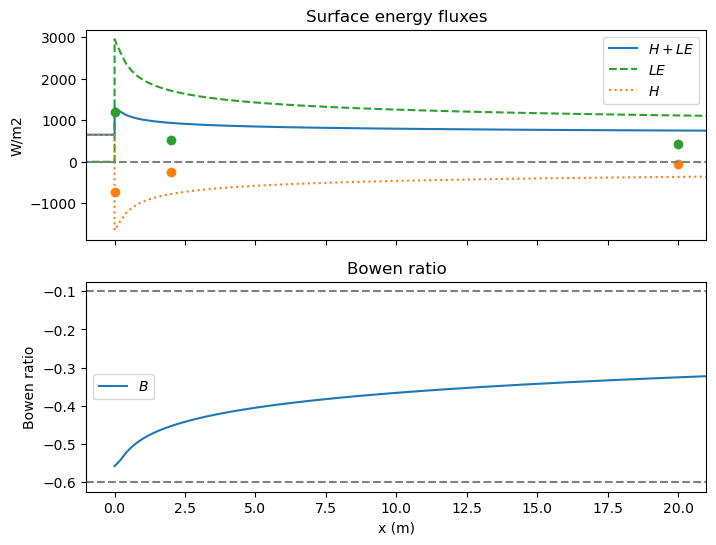

In [30]:
fig, axes = plt.subplots( 2, 1, figsize = (8, 6 ), sharex = True)
ax = axes[0]

xx = np.concatenate([-np.flip(x),x])
FluxTotal_ = np.concatenate([FluxTotal_upwind, FluxTotal[:, level]])

LE_Wm2 = np.concatenate([ LE_upwind_Wm2[level]*np.ones_like(x), LE_uniform_Wm2[:, level]])
H_Wm2 = np.concatenate([ H_upwind_Wm2[level]*np.ones_like(x), H_uniform_Wm2[:, level]])

ax.plot(xx, FluxTotal_,  c =  'C0', ls = '-', label = '$H + LE$')
ax.plot(xx, LE_Wm2,  ls = '--', c =  'C2',  label = "$LE$")
ax.plot(xx, H_Wm2,  ls = ':', c =  'C1',  label = "$H$")
ax.set_xlim(-1, 21)
ax.legend()
ax.plot(2, H_c2, 'C1o')
ax.plot(2, LE_c2, 'C2o')

ax.plot(20, H_c20, 'C1o')
ax.plot(20, LE_c20, 'C2o')

ax.plot(0, H_c0, 'C1o')
ax.plot(0, LE_c0, 'C2o')
ax.set_ylabel("W/m2")
ax.set_title("Surface energy fluxes")
ax.axhline(0, ls = '--', c = 'grey')

ax = axes[1]
ax.plot(x, (H_uniform_Wm2[:, level])/LE_uniform_Wm2[:, level], label = "$B$")
ax.set_title("Bowen ratio")
plt.xlabel("x (m)")
plt.ylabel("Bowen ratio")
ax.axhline(-0.1, ls = '--', c = 'grey')
ax.axhline(-0.6, ls = '--', c = 'grey')
plt.legend()


In [36]:
import re
from pathlib import Path
from typing import Union, Optional

import numpy as np
import pandas as pd

# Matches headers like: "T_x+18.5", "Rao_x-4.63", "T-x+1.15", etc.
_HEADER_PATTERN = re.compile(
    r'^\s*(?P<series>[A-Za-z]+)\s*[_\-]x\s*(?P<sign>[+\-])\s*(?P<xval>\d+(?:\.\d+)?)\s*$')

def parse_rao_wide_to_long(
    data: Union[str, Path, pd.DataFrame],
    start_row: int = 1) -> pd.DataFrame:
    """
    Parse a Rao-style wide digitized table into tidy long format.

    Parameters
    ----------
    data : str | Path | pd.DataFrame
        CSV path or a preloaded DataFrame with paired columns like:
        ['T_x+18.5', 'Unnamed: 1', 'T_x+1.15', 'Unnamed: 3', ...]
        First row contains 'X' (temperature) and 'Y' (height) labels per pair.
    start_row : int
        Row index where numeric data begin (default 1; row 0 = labels).

    Returns
    -------
    pd.DataFrame
        Columns: ['series', 'x', 'T', 'z'] where:
          - series: prefix from header (e.g., 'T', 'Rao')
          - x: horizontal distance (float), signed
          - T: temperature values (from the first-of-pair column)
          - z: vertical height values (from the second-of-pair column)
    """
    # Load input
    if isinstance(data, (str, Path)):
        df_raw = pd.read_csv(data)
    elif isinstance(data, pd.DataFrame):
        df_raw = data.copy()
    else:
        raise TypeError("`data` must be a path or a pandas DataFrame.")

    rows = []
    cols = list(df_raw.columns)
    i = 0
    n = len(cols)

    while i < n:
        col_a = cols[i]
        m = _HEADER_PATTERN.match(str(col_a))
        if m:
            col_b = cols[i + 1] if (i + 1) < n else None

            series = m.group("series")
            sign   = m.group("sign")
            xval   = float(m.group("xval"))
            x = xval if sign == "+" else -xval

            T_vals = pd.to_numeric(df_raw[col_a].iloc[start_row:], errors="coerce").values
            if col_b is not None:
                z_vals = pd.to_numeric(df_raw[col_b].iloc[start_row:], errors="coerce").values
            else:
                z_vals = np.full_like(T_vals, np.nan, dtype=float)

            mlen = min(len(T_vals), len(z_vals))
            T_vals = T_vals[:mlen]
            z_vals = z_vals[:mlen]

            mask = ~(np.isnan(T_vals) & np.isnan(z_vals))
            T_vals = T_vals[mask]
            z_vals = z_vals[mask]

            for Tv, zv in zip(T_vals, z_vals):
                if not (np.isfinite(Tv) or np.isfinite(zv)):
                    continue
                rows.append({"series": series, "x": x, "T": Tv, "z": zv})

            i += 2  # advance past the pair
        else:
            i += 1  # skip non-matching column

    long_df = pd.DataFrame(rows)
    if not long_df.empty:
        long_df = long_df.sort_values(["series", "x", "z"], kind="mergesort").reset_index(drop=True)
    return long_df


# ---- Example usage (no printing, no saving, just DataFrames) ----
fig1_long = parse_rao_wide_to_long("../data/Rao_1974_Figure1.csv")
fig2_long = parse_rao_wide_to_long("../data/Rao_1974_Figure2.csv")



In [37]:
fig1_long

,series,x,T,z
0,Rao,0.00,38.900409,0.011035
1,Rao,0.00,37.668646,0.015161
2,Rao,0.00,34.538626,0.042016
3,Rao,0.00,31.133835,0.462509
4,Rao,0.00,30.082805,9.135594
5,Rao,1.15,30.390386,0.011028
6,Rao,1.15,31.189955,0.016683
7,Rao,1.15,32.824456,0.050589
8,Rao,1.15,31.982259,0.172813
9,Rao,1.15,31.051930,0.512759


In [43]:
# Matches headers like: "Rao_x=18.5", "Rider_x=1.15", "T_x=0", etc.
_WPD_HEADER_PATTERN = re.compile(
    r'^\s*(?P<series>[A-Za-z]+(?:_[A-Za-z]+)*)\s*_x\s*=\s*(?P<xval>-?\d+(?:\.\d+)?)\s*$'
)

def parse_wpd_to_long(
    data: Union[str, Path, pd.DataFrame],
    label_row: int = 1,
    value_col: str = "T",
) -> pd.DataFrame:
    """
    Parse a WebPlotDigitizer (WPD) wide CSV into tidy long format.

    The expected layout is:
      Row 0  : series headers, e.g. 'Rao_x=18.5', '', 'Rider_x=4.63', '', ...
      Row 1  : column-role labels 'X', 'Y', 'X', 'Y', ...  (skipped)
      Row 2+ : numeric data — each pair (col_a, col_b) is (value, z)

    Parameters
    ----------
    data : str | Path | pd.DataFrame
        CSV path or a preloaded DataFrame (header=0 assumed).
    label_row : int
        Index of the X/Y label row to skip (default 1).
    value_col : str
        Name for the value column, e.g. 'T' for temperature or 'Q' for humidity.

    Returns
    -------
    pd.DataFrame
        Columns: ['series', 'x', value_col, 'z'].
    """
    if isinstance(data, (str, Path)):
        df_raw = pd.read_csv(data, header=0)
    elif isinstance(data, pd.DataFrame):
        df_raw = data.copy()
    else:
        raise TypeError("`data` must be a path or a pandas DataFrame.")

    start_row = label_row + 1   # skip the X/Y label row
    rows = []
    cols = list(df_raw.columns)
    n = len(cols)
    i = 0

    while i < n:
        col_a = cols[i]
        m = _WPD_HEADER_PATTERN.match(str(col_a))
        if m:
            col_b = cols[i + 1] if (i + 1) < n else None

            series = m.group("series")
            x      = float(m.group("xval"))

            v_vals = pd.to_numeric(df_raw[col_a].iloc[start_row:], errors="coerce").values
            if col_b is not None:
                z_vals = pd.to_numeric(df_raw[col_b].iloc[start_row:], errors="coerce").values
            else:
                z_vals = np.full_like(v_vals, np.nan, dtype=float)

            mlen   = min(len(v_vals), len(z_vals))
            v_vals = v_vals[:mlen]
            z_vals = z_vals[:mlen]

            mask   = ~(np.isnan(v_vals) & np.isnan(z_vals))
            v_vals = v_vals[mask]
            z_vals = z_vals[mask]

            for vv, zv in zip(v_vals, z_vals):
                if not (np.isfinite(vv) or np.isfinite(zv)):
                    continue
                rows.append({"series": series, "x": x, value_col: vv, "z": zv})

            i += 2  # advance past the (value, z) pair
        else:
            i += 1  # skip unnamed / non-matching column

    long_df = pd.DataFrame(rows)
    if not long_df.empty:
        long_df = long_df.sort_values(["series", "x", "z"], kind="mergesort").reset_index(drop=True)
    return long_df


fig1_long = parse_wpd_to_long("../data/Rao_1974_Figure1_T.csv", value_col="T")
fig2_long = parse_wpd_to_long("../data/Rao_1974_Figure2_Q.csv", value_col="Q")

print(fig2_long.groupby(["series", "x"]).size().rename("n_points").to_string())
fig2_long


series  x    
Rao     0.00     6
        1.15     6
        4.63     6
        18.50    6
Rider   0.00     4
        1.50     4
        4.63     4
        18.50    4


,series,x,Q,z
0,Rao,0.00,7.551020,0.010996
1,Rao,0.00,7.530612,0.048480
2,Rao,0.00,7.591837,0.112602
3,Rao,0.00,7.551020,0.267815
4,Rao,0.00,7.591837,0.614695
5,Rao,0.00,7.591837,1.497124
6,Rao,1.15,11.857143,0.010738
7,Rao,1.15,8.489796,0.047908
8,Rao,1.15,7.591837,0.112602
9,Rao,1.15,7.591837,0.271013


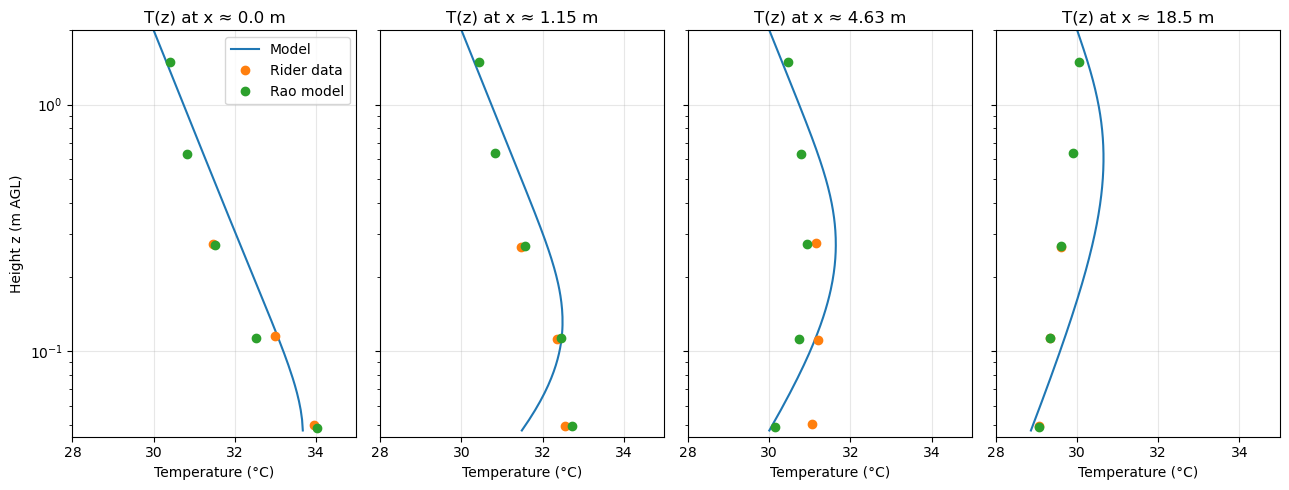

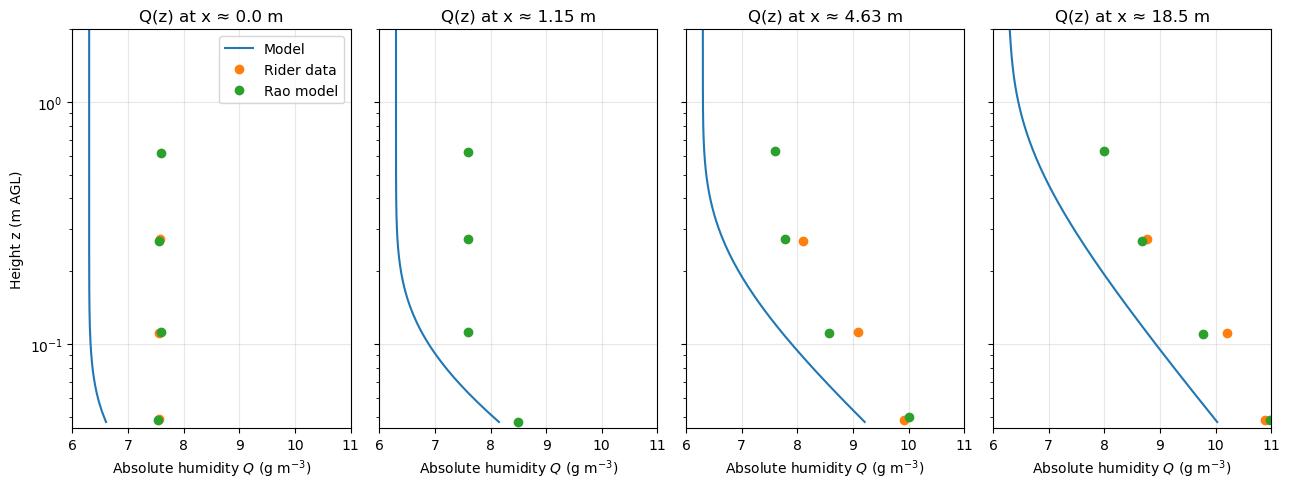

In [48]:
LOG_Y = True

# --------- T profiles (digitized Fig. 1 vs model T_uniform) ---------
x_panels_T = [0.0, 1.15, 4.63, 18.5]

fig, axes = plt.subplots(1, 4, figsize=(13, 5), sharey=True)

ind0 = np.where(p.z>0.04)[0][0]
for ax, x_plot in zip(axes, x_panels_T):
    # nearest model x to desired location
    ind = np.argmin(np.abs(p.x - x_plot))
    
    # model profile
    ax.plot(T_uniform[ind][ind0:], p.z[ind0:] + p.d_c, label="Model")
    
    # Rider digitized profile
    d1 = fig1_long.query(f"x == {x_plot} and series == 'Rider'")
    ax.plot(d1["T"][:-1], d1["z"][:-1], "o", label="Rider data")
    
    
    # Rider digitized profile
    d1 = fig1_long.query(f"x == {x_plot} and series == 'Rao'")
    ax.plot(d1["T"][:], d1["z"][:], "o", label="Rao model")    
    
    ax.set_title(f"T(z) at x ≈ {x_plot} m")
    ax.set_xlabel("Temperature (°C)")
    ax.grid(True, alpha=0.3)
    ax.set_ylim(0.045,2)
# Only left-most panel gets y-label and legend
axes[0].set_ylabel("Height z (m AGL)")
axes[0].legend()

# Apply y-scale toggle
for ax in axes:
    ax.set_yscale("log" if LOG_Y else "linear")
    ax.set_xlim(28, 35)
plt.tight_layout()


# --------- Q profiles (digitized Fig. 2 vs model Q_uniform) ---------
x_panels_Q = [0.0, 1.15, 4.63, 18.5]

fig, axes = plt.subplots(1, 4, figsize=(13, 5), sharey=True)

for ax, x_plot in zip(axes, x_panels_Q):
    # nearest model x to desired location
    ind = np.argmin(np.abs(p.x - x_plot))
    
    # model profile
    ax.plot(Q_uniform[ind][ind0:], p.z[ind0:] + p.d_c, "-", label="Model")
    
    # Rider digitized profile (column "T" holds Q for Fig. 2)
    d1 = fig2_long.query(f"x == {x_plot} and series == 'Rider'")
    ax.plot(d1["Q"][:-1], d1["z"][:-1], "o", label="Rider data")
    
    # Rider digitized profile (column "T" holds Q for Fig. 2)
    d1 = fig2_long.query(f"x == {x_plot} and series == 'Rao'")
    ax.plot(d1["Q"][:-1], d1["z"][:-1], "o", label="Rao model")    
    
    ax.set_title(f"Q(z) at x ≈ {x_plot} m")
    ax.set_xlabel(r"Absolute humidity $Q$ (g m$^{-3}$)")
    ax.grid(True, alpha=0.3)
    ax.set_ylim(0.045,2)
axes[0].set_ylabel("Height z (m AGL)")
axes[0].legend()

for ax in axes:
    ax.set_yscale("log" if LOG_Y else "linear")
    ax.set_xlim(6,11)
plt.tight_layout()



In [ ]:
import numpy as np

def profile_rmse(model_profile, model_z, rider_vals, rider_z):
    """Interpolate model profile to Rider z and return RMSE."""
    model_z = np.asarray(model_z)
    model_profile = np.asarray(model_profile)

    # sort by height just in case
    order = np.argsort(model_z)
    mz = model_z[order]
    mp = model_profile[order]

    mp_at_rz = np.interp(rider_z, mz, mp)
    return np.sqrt(np.mean((mp_at_rz - rider_vals) ** 2))


# x-locations to compare (same as plots: 0, 1.15, 4.63, 18.5 m)
x_locs = [0.0, 1.15, 4.63, 18.5]

rmse_T = []
rmse_Q = []

# ---------- T profiles RMSE ----------
for x_plot in x_locs:
    # nearest model x
    ind = np.argmin(np.abs(p.x - x_plot))

    model_z = p.z + p.d_c          # z AGL with zero-plane displacement
    model_T = T_uniform[ind]

    d1 = fig1_long.query(f"x == {x_plot} and series == 'T'")
    rider_z = d1["z"].values[:-1]  # same truncation as in plots
    rider_T = d1["T"].values[:-1]

    rmse_T.append(profile_rmse(model_T, model_z, rider_T, rider_z))

# ---------- Q profiles RMSE ----------
for x_plot in x_locs:
    ind = np.argmin(np.abs(p.x - x_plot))

    model_z = p.z + p.d_c          # same height definition as T comparison
    model_Q = Q_uniform[ind]

    d2 = fig2_long.query(f"x == {x_plot} and series == 'E'")
    rider_z = d2["z"].values[:-1]
    rider_Q = d2["T"].values[:-1]  # digitized Q stored in column "T"

    rmse_Q.append(profile_rmse(model_Q, model_z, rider_Q, rider_z))


# ---------- Pretty printing as simple “table” (no tabulate) ----------
print("Temperature RMSE (model vs Rider):")
header = "x (m)   " + "  ".join(f"{x:7.2f}" for x in x_locs)
row_T  = "RMSE_T  " + "  ".join(f"{v:7.3f}" for v in rmse_T)
print(header)
print(row_T)

print("\nAbsolute humidity RMSE (model vs Rider):")
header = "x (m)   " + "  ".join(f"{x:7.2f}" for x in x_locs)
row_Q  = "RMSE_Q  " + "  ".join(f"{v:7.3f}" for v in rmse_Q)
print(header)
print(row_Q)


In [45]:
# --- RMSE helper ---
def profile_rmse(model_profile, model_z, rider_vals, rider_z):
    """Interpolate model profile to Rider z and return RMSE."""
    model_z = np.asarray(model_z)
    model_profile = np.asarray(model_profile)

    if len(rider_z) == 0 or len(rider_vals) == 0:
        return np.nan

    order = np.argsort(model_z)
    mz = model_z[order]
    mp = model_profile[order]

    mp_at_rz = np.interp(rider_z, mz, mp)
    return np.sqrt(np.mean((mp_at_rz - rider_vals) ** 2))


def compute_rmse_for_case(p: Params, T_uniform, Q_uniform,
                          x_locs=(0.0, 1.15, 4.63, 18.5)):
    """
    Compute RMSE arrays for T and Q at the given x locations,
    using z + d_c as the model height coordinate.
    """
    rmse_T = []
    rmse_Q = []

    z_model = p.z + p.d_c  # AGL, consistent with your plots

    for x_plot in x_locs:
        ix = np.argmin(np.abs(p.x - x_plot))

        # --- Temperature RMSE ---
        d1 = fig1_long.query(f"x == {x_plot} and series == 'T'")
        rider_z_T = d1["z"].values[:-1]
        rider_T   = d1["T"].values[:-1]
        model_T   = T_uniform[ix, :]

        rmse_T.append(profile_rmse(model_T, z_model, rider_T, rider_z_T))

        # --- Absolute humidity RMSE ---
        d2 = fig2_long.query(f"x == {x_plot} and series == 'E'")
        rider_z_Q = d2["z"].values[:-1]
        rider_Q   = d2["T"].values[:-1]   # Q digitized into column "T"
        model_Q   = Q_uniform[ix, :]

        rmse_Q.append(profile_rmse(model_Q, z_model, rider_Q, rider_z_Q))

    return np.array(rmse_T), np.array(rmse_Q)


# --------------------------------------------------------------------
# 1D sweep over ustar_f only (with tunable lm_zshift)
# --------------------------------------------------------------------
def sweep_ustar_f(ustar_f_values, shear_ratio: float = 1.0,
                  x_locs=(0.0, 1.15, 4.63, 18.5),
                  lm_zshift: float = 0.005):
    """
    For each ustar_f:
      * build Params
      * run radiation + BC updates
      * solve uniform_T / uniform_Q
      * compute RMSE vs Rider at x_locs

    Returns
    -------
    df_T, df_Q : pandas.DataFrame
        index  = ustar_f
        cols   = x-locations + 'mean'
    """
    rmse_T_all = []
    rmse_Q_all = []

    for ustar_f in ustar_f_values:
        ustar_c = ustar_f * np.sqrt(shear_ratio)

        p = Params(
            ustar_f=ustar_f,
            ustar_c=ustar_c,
            lm_option='kz',
            lm_zshift=lm_zshift,
            avail_ratio=1.2,
            Hmax=2.0,
            le_factor=1.2,
            dz=0.005,
            dx=0.1,
        )

        # radiation + BC updates
        p.solve_surface_radiation_inplace(fix="alpha_c")
        p.update_surface_BCs_from_zom()
        p.update_surface_BCs_from_reference()

        # solve fields
        T_uniform, _ = uniform_T(p)
        Q_uniform, _ = uniform_Q(p)

        rmse_T, rmse_Q = compute_rmse_for_case(p, T_uniform, Q_uniform, x_locs)

        rmse_T_all.append(rmse_T)
        rmse_Q_all.append(rmse_Q)

    rmse_T_all = np.array(rmse_T_all)
    rmse_Q_all = np.array(rmse_Q_all)

    x_cols = [f"x={float(x):.2f} m" for x in x_locs]

    df_T = pd.DataFrame(rmse_T_all, index=ustar_f_values, columns=x_cols)
    df_T.index.name = "ustar_f"
    df_T["mean"] = df_T.mean(axis=1)   # mean over x for each ustar_f

    df_Q = pd.DataFrame(rmse_Q_all, index=ustar_f_values, columns=x_cols)
    df_Q.index.name = "ustar_f"
    df_Q["mean"] = df_Q.mean(axis=1)

    return df_T, df_Q


# --------------------------------------------------------------------
# 3D gridded sweep over (ustar_f, zom_c, lm_zshift)
# --------------------------------------------------------------------
def sweep_ustar_f_zom_c_lmshift(ustar_f_values, zom_c_values, lm_zshift_values,
                                shear_ratio: float = 1.0,
                                x_locs=(0.0, 1.15, 4.63, 18.5)):
    """
    Gridded sweep over ustar_f, zom_c, and lm_zshift.

    For each (ustar_f, zom_c, lm_zshift) triplet:
      * build Params
      * run radiation + BC updates
      * solve uniform_T / uniform_Q
      * compute RMSE vs Rider at x_locs

    Returns
    -------
    df_T_grid, df_Q_grid : pandas.DataFrame
        index  = MultiIndex[ustar_f, zom_c, lm_zshift]
        cols   = x-locations + 'mean'
    """
    rows_T = []
    rows_Q = []

    for ustar_f in ustar_f_values:
        ustar_c = ustar_f * np.sqrt(shear_ratio)

        for zom_c in zom_c_values:
            for lm_zshift in lm_zshift_values:

                p = Params(
                    ustar_f=ustar_f,
                    ustar_c=ustar_c,
                    zom_c=zom_c,
                    lm_option='kz',
                    lm_zshift=lm_zshift,
                    avail_ratio=1.2,
                    Hmax=2.0,
                    le_factor=1.2,
                    dz=0.005,
                    dx=0.2,
                )

                p.solve_surface_radiation_inplace(fix="alpha_c")
                p.update_surface_BCs_from_zom()
                p.update_surface_BCs_from_reference()

                T_uniform, _ = uniform_T(p)
                Q_uniform, _ = uniform_Q(p)

                rmse_T, rmse_Q = compute_rmse_for_case(p, T_uniform, Q_uniform, x_locs)

                x_cols = [f"x={float(x):.2f} m" for x in x_locs]

                row_T = {"ustar_f": ustar_f, "zom_c": zom_c, "lm_zshift": lm_zshift}
                row_Q = {"ustar_f": ustar_f, "zom_c": zom_c, "lm_zshift": lm_zshift}

                for xc, rt, rq in zip(x_cols, rmse_T, rmse_Q):
                    row_T[xc] = rt
                    row_Q[xc] = rq

                rows_T.append(row_T)
                rows_Q.append(row_Q)

    df_T_grid = pd.DataFrame(rows_T).set_index(["ustar_f", "zom_c", "lm_zshift"])
    df_Q_grid = pd.DataFrame(rows_Q).set_index(["ustar_f", "zom_c", "lm_zshift"])

    # add mean-over-x column for each (ustar_f, zom_c, lm_zshift)
    x_cols = [c for c in df_T_grid.columns if c.startswith("x=")]
    df_T_grid["mean"] = df_T_grid[x_cols].mean(axis=1)
    df_Q_grid["mean"] = df_Q_grid[x_cols].mean(axis=1)

    return df_T_grid, df_Q_grid


ustar_vals   = [ 0.3, 0.5, 0.6, 0.7, 0.8]
zom_vals     = [2e-4, 5e-4, 1e-3]
lm_shifts    = [0.0, 0.0025, 0.005, 0.01]

df_T_grid, df_Q_grid = sweep_ustar_f_zom_c_lmshift(
    ustar_vals, zom_vals, lm_shifts
)

# e.g. minimum mean T-RMSE combo:
df_T_grid["mean"].idxmin(), df_T_grid["mean"].min()

KeyError: 'T'

In [ ]:
df_T_grid.sort_values('mean').head(5)


In [ ]:
df_Q_grid.sort_values('mean').head(5)

In [ ]:
import numpy as np
import pandas as pd

# --- RMSE helper (unchanged) ---
def profile_rmse(model_profile, model_z, rider_vals, rider_z):
    """Interpolate model profile to Rider z and return RMSE."""
    model_z = np.asarray(model_z)
    model_profile = np.asarray(model_profile)

    if len(rider_z) == 0 or len(rider_vals) == 0:
        return np.nan

    order = np.argsort(model_z)
    mz = model_z[order]
    mp = model_profile[order]

    mp_at_rz = np.interp(rider_z, mz, mp)
    return np.sqrt(np.mean((mp_at_rz - rider_vals) ** 2))


def compute_rmse_for_case(p: Params, T_uniform, Q_uniform,
                          x_locs=(0.0, 1.15, 4.63, 18.5)):
    """
    Compute RMSE arrays for T and Q at the given x locations,
    using z + d_c as the model height coordinate.
    """
    rmse_T = []
    rmse_Q = []

    z_model = p.z + p.d_c  # AGL, consistent with your plots

    for x_plot in x_locs:
        ix = np.argmin(np.abs(p.x - x_plot))

        # --- Temperature RMSE ---
        d1 = fig1_long.query(f"x == {x_plot} and series == 'T'")
        rider_z_T = d1["z"].values[:-1]
        rider_T   = d1["T"].values[:-1]
        model_T   = T_uniform[ix, :]

        rmse_T.append(profile_rmse(model_T, z_model, rider_T, rider_z_T))

        # --- Absolute humidity RMSE ---
        d2 = fig2_long.query(f"x == {x_plot} and series == 'E'")
        rider_z_Q = d2["z"].values[:-1]
        rider_Q   = d2["T"].values[:-1]   # Q digitized into column "T"
        model_Q   = Q_uniform[ix, :]

        rmse_Q.append(profile_rmse(model_Q, z_model, rider_Q, rider_z_Q))

    return np.array(rmse_T), np.array(rmse_Q)


# --------------------------------------------------------------------
# 1D sweep over ustar_f only (with tunable lm_zshift, avail_ratio, le_factor)
# --------------------------------------------------------------------
def sweep_ustar_f(
    ustar_f_values,
    shear_ratio: float = 1.0,
    x_locs=(0.0, 1.15, 4.63, 18.5),
    lm_zshift: float = 0.005,
    avail_ratio: float = 1.2,
    le_factor: float = 1.2,
):
    """
    For each ustar_f:
      * build Params
      * run radiation + BC updates
      * solve uniform_T / uniform_Q
      * compute RMSE vs Rider at x_locs

    Returns
    -------
    df_T, df_Q : pandas.DataFrame
        index  = ustar_f
        cols   = x-locations + 'mean'
    """
    rmse_T_all = []
    rmse_Q_all = []

    for ustar_f in ustar_f_values:
        ustar_c = ustar_f * np.sqrt(shear_ratio)

        p = Params(
            ustar_f=ustar_f,
            ustar_c=ustar_c,
            lm_option='kz',
            lm_zshift=lm_zshift,
            avail_ratio=avail_ratio,
            le_factor=le_factor,
            Hmax=2.0,
            dz=0.005,
            dx=0.1,
        )

        # radiation + BC updates
        p.solve_surface_radiation_inplace(fix="alpha_c")
        p.update_surface_BCs_from_zom()
        p.update_surface_BCs_from_reference()

        # solve fields
        T_uniform, _ = uniform_T(p)
        Q_uniform, _ = uniform_Q(p)

        rmse_T, rmse_Q = compute_rmse_for_case(p, T_uniform, Q_uniform, x_locs)

        rmse_T_all.append(rmse_T)
        rmse_Q_all.append(rmse_Q)

    rmse_T_all = np.array(rmse_T_all)
    rmse_Q_all = np.array(rmse_Q_all)

    x_cols = [f"x={float(x):.2f} m" for x in x_locs]

    df_T = pd.DataFrame(rmse_T_all, index=ustar_f_values, columns=x_cols)
    df_T.index.name = "ustar_f"
    df_T["mean"] = df_T.mean(axis=1)

    df_Q = pd.DataFrame(rmse_Q_all, index=ustar_f_values, columns=x_cols)
    df_Q.index.name = "ustar_f"
    df_Q["mean"] = df_Q.mean(axis=1)

    return df_T, df_Q


# --------------------------------------------------------------------
# 5D gridded sweep over (ustar_f, zom_c, lm_zshift, avail_ratio, le_factor)
# --------------------------------------------------------------------
def sweep_ustar_f_zom_c_lmshift_le(
    ustar_f_values,
    zom_c_values,
    lm_zshift_values,
    avail_ratio_values,
    le_factor_values,
    shear_ratio: float = 1.0,
    x_locs=(0.0, 1.15, 4.63, 18.5),
):
    """
    Gridded sweep over ustar_f, zom_c, lm_zshift, avail_ratio, and le_factor.

    For each combination:
      * build Params
      * run radiation + BC updates
      * solve uniform_T / uniform_Q
      * compute RMSE vs Rider at x_locs

    Returns
    -------
    df_T_grid, df_Q_grid : pandas.DataFrame
        index  = MultiIndex[ustar_f, zom_c, lm_zshift, avail_ratio, le_factor]
        cols   = x-locations + 'mean'
    """
    rows_T = []
    rows_Q = []

    for ustar_f in ustar_f_values:
        ustar_c = ustar_f * np.sqrt(shear_ratio)

        for zom_c in zom_c_values:
            for lm_zshift in lm_zshift_values:
                for avail_ratio in avail_ratio_values:
                    for le_factor in le_factor_values:

                        p = Params(
                            ustar_f=ustar_f,
                            ustar_c=ustar_c,
                            zom_c=zom_c,
                            lm_option='kz',
                            lm_zshift=lm_zshift,
                            avail_ratio=avail_ratio,
                            le_factor=le_factor,
                            Hmax=2.0,
                            dz=0.005,
                            dx=0.2,   # your choice from previous snippet
                        )

                        p.solve_surface_radiation_inplace(fix="alpha_c")
                        p.update_surface_BCs_from_zom()
                        p.update_surface_BCs_from_reference()

                        T_uniform, _ = uniform_T(p)
                        Q_uniform, _ = uniform_Q(p)

                        rmse_T, rmse_Q = compute_rmse_for_case(
                            p, T_uniform, Q_uniform, x_locs
                        )

                        x_cols = [f"x={float(x):.2f} m" for x in x_locs]

                        row_T = {
                            "ustar_f": ustar_f,
                            "zom_c": zom_c,
                            "lm_zshift": lm_zshift,
                            "avail_ratio": avail_ratio,
                            "le_factor": le_factor,
                        }
                        row_Q = row_T.copy()

                        for xc, rt, rq in zip(x_cols, rmse_T, rmse_Q):
                            row_T[xc] = rt
                            row_Q[xc] = rq

                        rows_T.append(row_T)
                        rows_Q.append(row_Q)

    df_T_grid = pd.DataFrame(rows_T).set_index(
        ["ustar_f", "zom_c", "lm_zshift", "avail_ratio", "le_factor"]
    )
    df_Q_grid = pd.DataFrame(rows_Q).set_index(
        ["ustar_f", "zom_c", "lm_zshift", "avail_ratio", "le_factor"]
    )

    x_cols = [c for c in df_T_grid.columns if c.startswith("x=")]
    df_T_grid["mean"] = df_T_grid[x_cols].mean(axis=1)
    df_Q_grid["mean"] = df_Q_grid[x_cols].mean(axis=1)

    return df_T_grid, df_Q_grid

ustar_vals = [0.5, 0.6, 0.7, 0.8, 0.9]
zom_vals   = [2e-4, 5e-4, 1e-3]
lm_shifts  = [0.0, 0.001, 0.0025, 0.005, 0.01]
avail_vals = [1.0, 1.1, 1.2, 1.3]
le_vals    = [0.8, 0.9, 1.0, 1.2, 1.3]

df_T_grid, df_Q_grid = sweep_ustar_f_zom_c_lmshift_le(
    ustar_vals, zom_vals, lm_shifts, avail_vals, le_vals
)

# Best mean T-fit combo:
df_T_grid["mean"].idxmin(), df_T_grid["mean"].min()

In [ ]:
df_T_grid.sort_values('mean').query("mean < 0.37").head()

In [ ]:
df_Q_grid.sort_values('x=18.50 m').query("mean < 0.34")

In [ ]:

# zmin = zom + d 
# adjust 
# 5 cm
# predict flux. 
# z = zmin ... zmax


In [ ]:
fig, axes = plt.subplots( 2, 1, figsize = (8, 6 ), sharex = True)
ax = axes[0]
xx =  np.concatenate([-np.flip(x),x])
# FluxTotal_ = np.concatenate([FluxTotal_upwind, FluxTotal[:, level]])

level = 0
Q = np.concatenate([ Q_up[level]*np.ones_like(x), Q_uniform[:, level]])
T = np.concatenate([ T_up[level]*np.ones_like(x), T_uniform[:, level]])

ax.plot(xx[1:], (Q[1:]),  ls = '--', c =  'C2',  label = "$Q$")
ax.plot(xx[1:], (T[1:]),  ls = ':', c =  'C1',  label = "$T$")
ax.set_xlim(0, 21)

# ax.set_yscale('log')
ax.legend()

ax = axes[1]
x = p.x

ax.plot(x, (H_uniform_Wm2[:, level])/LE_uniform_Wm2[:, level], label = "$B$")
plt.xlabel("x (m)")
plt.ylabel("Bowen ratio")
ax.axhline(-0.1, ls = '--', c = 'grey')
ax.axhline(-0.6, ls = '--', c = 'grey')

plt.legend()
# Sensible heat flux needs to move to 0 faster than LE moves to LE_c? 

In [ ]:
level = 0
fig, axes = plt.subplots( 2, 1, figsize = (8, 6 ), sharex = True)
ax = axes[0]

xx = np.concatenate([-np.flip(x),x])
FluxTotal_ = np.concatenate([FluxTotal_upwind, FluxTotal[:, level]])

LE_Wm2 = np.concatenate([ LE_upwind_Wm2[level]*np.ones_like(x), LE_uniform_Wm2[:, level]])
H_Wm2 = np.concatenate([ H_upwind_Wm2[level]*np.ones_like(x), H_uniform_Wm2[:, level]])

ax.plot(p.x[2:], np.diff(LE_uniform_Wm2[1:,level]),  ls = '--', c =  'C2',  label = "$LE$")
ax.plot(p.x[2:], - np.diff(H_uniform_Wm2[1:, level]),  ls = ':', c =  'C1',  label = "$H$")
ax.set_xlim(0, 21)

# ax.set_yscale('log')
ax.legend()

ax = axes[1]
x = p.x

ax.plot(x, (H_uniform_Wm2[:, level])/LE_uniform_Wm2[:, level], label = "$B$")
plt.xlabel("x (m)")
plt.ylabel("Bowen ratio")
ax.axhline(-0.1, ls = '--', c = 'grey')
ax.axhline(-0.6, ls = '--', c = 'grey')

plt.legend()
# Sensible heat flux needs to move to 0 faster than LE moves to LE_c? 

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# ---------------- gradient-based flux checks (using two-point logs) ----------------
# Downwind (last x)
le_last = p.ustar_c * p.k * (Q_uniform[-1, 1] - Q_uniform[-1, 0]) / np.log(p.z[0] / p.z[1]) * Lv_g
h_last  = p.ustar_c * p.k * (T_uniform[-1, 1] - T_uniform[-1, 0]) / np.log(p.z[0] / p.z[1]) * rho_air * cp_air

# Downwind (near-upstream, x index 1)
le_x1 = p.ustar_c * p.k * (Q_uniform[1, 1] - Q_uniform[1, 0]) / np.log(p.z[0] / p.z[1]) * Lv_g
h_x1  = p.ustar_c * p.k * (T_uniform[1, 1] - T_uniform[1, 0]) / np.log(p.z[0] / p.z[1]) * rho_air * cp_air

# Upwind
le_up = p.ustar_f * p.k * (Q_up[1] - Q_up[2]) / np.log(p.z[2] / p.z[1]) * Lv_g
h_up  = p.ustar_f * p.k * (T_up[1] - T_up[0]) / np.log(p.z[0] / p.z[1]) * rho_air * cp_air

# ---------------- figure with 3 subplots (larger fonts, consistent styles across subplots) ----------------
plt.rcParams.update({
    "font.size": 14,                # base font size
    "axes.titlesize": 16,
    "axes.labelsize": 15,
    "legend.fontsize": 13,
    "xtick.labelsize": 13,
    "ytick.labelsize": 13,
})

fig, axes = plt.subplots(1, 3, figsize=(14, 5.2), sharey=True)

# Common styles (do not change between subplots)
style_LE = dict(color='C2', linestyle='--', linewidth=2.0, label='$LE$')
style_H  = dict(color='C1', linestyle='-',  linewidth=2.0, label='$H$')

# Panel 1: Downwind (last x) vertical profiles
ax = axes[0]
ax.plot(LE_uniform_Wm2[-1, :], p.z, **style_LE)
ax.plot(H_uniform_Wm2[-1, :],  p.z, **style_H)
ax.set_title("Downwind flux profiles (last x)")
ax.set_xlabel("Flux (W m$^{-2}$)")
ax.set_ylabel("z (m)")
ax.grid(True, alpha=0.3)
ax.legend(loc='upper right')
ax.tick_params(length=6, width=1)

txt1 = (f"LE   : {le_last:6.1f}\n"
        f"LE : {le_last:6.1f}\n"
        f"H  : {h_last:6.1f}")
ax.text(0.03, 0.03, txt1, transform=ax.transAxes, fontsize=12,
        bbox=dict(facecolor='white', alpha=0.75, edgecolor='none'))

# Panel 2: Downwind (x=1) vertical profiles
ax = axes[1]
ax.plot(LE_uniform_Wm2[1, :], p.z, **style_LE)
ax.plot(H_uniform_Wm2[1, :],  p.z, **style_H)
ax.set_title("Downwind flux profiles (x = 0.2)")
ax.set_xlabel("Flux (W m$^{-2}$)")
ax.grid(True, alpha=0.3)
# ax.legend(loc='best')
ax.tick_params(length=6, width=1)

txt2 = (f"LE : {le_x1:6.1f}\n"
        f"H  : {h_x1:6.1f}")
ax.text(0.03, 0.03, txt2, transform=ax.transAxes, fontsize=12,
        bbox=dict(facecolor='white', alpha=0.75, edgecolor='none'))

# Panel 3: Upwind vertical profiles
ax = axes[2]
ax.plot(LE_upwind_Wm2, p.z, **style_LE)
ax.plot(H_upwind_Wm2,  p.z, **style_H)
ax.set_title("Upwind flux profiles")
ax.set_xlabel("Flux (W m$^{-2}$)")
ax.grid(True, alpha=0.3)
# ax.legend(loc='best')
ax.tick_params(length=6, width=1)

txt3 = (f"LE : {le_up:6.1f}\n"
        f"H  : {h_up:6.1f}")
ax.text(0.03, 0.03, txt3, transform=ax.transAxes, fontsize=12,
        bbox=dict(facecolor='white', alpha=0.75, edgecolor='none'))

plt.tight_layout()

for ax in axes:
    ax.set_yscale('log')



In [ ]:
# Upwind checks

H_wall_Wm2  =  p.ustar_f * p.k * (p.T_sf - p.T_a) / np.log(p.Hmax / p.z[0]) * rho_air *cp_air

print("H_f (Params):       ", p.H_f)
print("H_wall:              {0:.2f}".format( H_wall_Wm2) ) 


# Downwind checks
# Lv_g = 2430.0  # J g^-1
Fq_wall_gm2s = p.ustar_c * p.k * (p.Q_c - p.Q_a) / np.log(p.Hmax / p.z[0])
LE_wall_Wm2  = Fq_wall_gm2s * Lv_g

print("\nLE_c (Params):      ", p.LE_c)
print("LE_wall:             {0:.2f} ".format(LE_wall_Wm2))  


\begin{aligned}
\mathrm{SW}\,(1-\alpha_f) + \varepsilon_a \,\sigma_{SB}\, T_a^{4}
  - \varepsilon_f \,\sigma_{SB}\, T_{sf}^{4} &= R_{n,f}, \\
\mathrm{SW}\,(1-\alpha_c) + \varepsilon_a \,\sigma_{SB}\, T_a^{4}
  - \varepsilon_c \,\sigma_{SB}\, T_{sc}^{4} &= R_{n,c}, \\
T_{sf} - T_a &= \frac{1}{k\,u_{*f}}\,
  \frac{H_f}{\rho\,c_p}\,
  \ln\!\left(\frac{z_h}{z_\ell}\right), \\
T_{sc} - T_a &= \frac{1}{k\,u_{*c}}\,
  \frac{H_c}{\rho\,c_p}\,
  \ln\!\left(\frac{z_h}{z_\ell}\right), \\
Q_c - Q_a &= \frac{1}{k\,u_{*c}}\,
  \frac{\mathrm{LE}_c}{L_v}\,
  \ln\!\left(\frac{z_h}{z_\ell}\right), \\
R_{n,c} - G &= \mathrm{LE}_c + H_c .
\end{aligned}

In [ ]:
z = p.z
x = p.x

# Plot water vapor concentration and vertical flux
plt.figure(figsize = (8, 6))

plt.subplot(2, 1, 1)
nz = Q_uniform.shape[1]
plt.contourf(x, z[:nz], (Q_uniform.T), 25, cmap='Blues',  vmax = p.Q_c, vmin =p.Q_a)
plt.colorbar(label='g m$^{-3}$')
plt.xlabel('x (m)', fontsize=12, fontweight='normal')
plt.ylabel('z (m)', fontsize=12, fontweight='normal')
plt.title('Water vapor concentration $q$ (g m$^{-3}$)', fontsize=12)

plt.subplot(2, 1, 2)
plt.contourf(x, z[:nz], FluxQ_uniform.T.round(4),  20, cmap='coolwarm', vmin = 0, vmax = FluxQ_uniform.max())
plt.colorbar(label='g m$^{-2}$ s$^{-1}$') 
plt.xlabel('x (m)', fontsize=12, fontweight='normal')
plt.ylabel('z (m)', fontsize=12, fontweight='normal')
plt.title('Water vapor flux (g m$^{-2}$ s$^{-1}$)', fontsize=12)
plt.tight_layout()



In [ ]:

level = 1
# rough estimate at level height z:
z_eff = z[level] - p.h_c*2/3
lm    = p.k * z_eff  
K     = lm * ustar_c
U = (p.ustar_f / p.k) * np.log(z / p.zom_c) 
Lrec  = U[level] * z_eff / (p.k * ustar_c)   

In [ ]:
Q_uniform.shape, p.z.shape

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from numpy.linalg import lstsq
from scipy.optimize import curve_fit
 
    
# -----------------  boundary + anchor points (edit if you read different values) -----------------
# x in meters; y in the figure’s flux units (“mk s^-1”)
x0, ySH0, yLH0 = 0.1,  -0.60,  1.00   # start (x=0)
xA, ySHA, yLHA = 2.0,  -0.20,  0.45   # 2 m
xB, ySHB, yLHB = 6.0,  -0.10,  0.4    # 6 m
xF, ySHF, yLHF = 20.0, -0.05,  0.36   # far downstream

# level = 1

x0, ySH0, yLH0 = p.x[0],  H_uniform_Wm2[0, level],  LE_uniform_Wm2[0, level]   # start (x=0)
xA, ySHA, yLHA = p.x[4], H_uniform_Wm2[4, level],  LE_uniform_Wm2[4, level]   # start (x=0)
xB, ySHB, yLHB = p.x[10], H_uniform_Wm2[10, level],  LE_uniform_Wm2[10, level]   # start (x=0)
xF, ySHF, yLHF = p.x[20], H_uniform_Wm2[20, level],  LE_uniform_Wm2[20, level]   # start (x=0)


# Choose a small positive shift so ln(x + x_shift) is defined at x=0.
x_shift = 0.001

x_pts   = np.array([x0, xA, xB, xF], float)
ySH_pts = np.array([ySH0, ySHA, ySHB, ySHF], float)
yLH_pts = np.array([yLH0, yLHA, yLHB, yLHF], float)

print(ySH_pts, )
def exp1(x, y_inf, L):
    # one-exponential with y0 fixed by the first point
    y0 = ySH0_or_yLH0 
    return y_inf + (y0 - y_inf) * np.exp(-x / L)

# Fit SH
ySH0_or_yLH0 = ySH0
p0_SH = (ySHF, 2.0)                              # initial guess: asymptote ~ far point
par_SH, _ = curve_fit(lambda x, y_inf, L: exp1(x, y_inf, L),
                      x_pts, ySH_pts, p0=p0_SH, maxfev=10000)
ySH_inf, L_SH = par_SH

# Fit LH
ySH0_or_yLH0 = yLH0
p0_LH = (yLHF, 2.0)
par_LH, _ = curve_fit(lambda x, y_inf, L: exp1(x, y_inf, L),
                      x_pts, yLH_pts, p0=p0_LH, maxfev=10000)
yLH_inf, L_LH = par_LH

# Evaluate
x = np.linspace(0, 20, 300)
SH_fit = ySH_inf + (ySH0 - ySH_inf)*np.exp(-x/L_SH)
LH_fit = yLH_inf + (yLH0 - yLH_inf)*np.exp(-x/L_LH)

SH_range = ySH0 - ySH_inf 
LH_range = yLH0 - yLH_inf
print(f"SH(x) ≈ {ySH_inf:.2f} + ({SH_range:.2f}) * exp(-x/{L_SH:.2f})")
print(f"LH(x) ≈ {yLH_inf:.2f} + ({LH_range:.2f}) * exp(-x/{L_LH:.2f})")


# ----------------- 4) plot -----------------
plt.figure(figsize=(7.5, 4.8))
plt.plot(x,  LH_fit,  'C2', lw=2.5, label='LH')
plt.plot(x,  -SH_fit,  'C1', lw=2.5, label='SH')
plt.scatter(x_pts, yLH_pts, c='C2', s=50, marker='o', label='')
plt.scatter(x_pts, -ySH_pts, c='C1', s=50, marker='s', label='')
plt.axhline(0, color='k', lw=0.7)
plt.xlim(0, 21); 
# plt.ylim(-0.65, 1.1)
plt.xlabel('x (m)')
plt.ylabel('Flux (mk s$^{-1}$)')
plt.title('Rao Fig. 4 — single-log fits using boundary + anchor')
plt.legend()
plt.tight_layout()
plt.show()




### Appendix

In [ ]:
# density depends on air temperature
import numpy as np

# --- constants ---
cp  = 1005.0          # J kg^-1 K^-1  (specific heat at constant pressure)
R_d = 287.05          # J kg^-1 K^-1  (gas constant for dry air)
p_Pa = 101325.0       # Pa (set your measured station pressure if available)

def air_density(T_K, p_Pa=101325.0, q_kgkg=None):
    """
    Air density [kg m^-3] from temperature (K), pressure (Pa), and optional specific humidity q (kg/kg).
    Uses virtual temperature: T_v = T*(1 + 0.61 q) if q is provided.
    """
    if q_kgkg is not None:
        T_v = T_K * (1.0 + 0.61*q_kgkg)
    else:
        T_v = T_K
    return p_Pa / (R_d * T_v)

# If you already have ambient humidity as Q_a in g/kg, use it for moist-air density.
# Otherwise we'll compute a dry-air density.
try:
    q_a = Q_a / 1000.0   # g/kg -> kg/kg
except NameError:
    q_a = None

T_a = 30
rho = air_density(T_a, p_Pa=p_Pa, q_kgkg=q_a)

# --- your original variables ---
zo = p.zom_f
ustar_f = 0.15
ustar_c = 0.15
k = p.k

# stability-neutral bulk transfer (ensure z_h > zo)
L = np.log(p.z[-1] / zo)      # dimensionless

# Use rho*cp instead of 1005*1.2
T_sc = T_a + (p.H_c/(rho*cp)) * (1.0/(k*ustar_c)) * L
print(T_sc - 273.15)

T_sf = T_a + (p.H_f/(rho*cp)) * (1.0/(k*ustar_f)) * L
print(T_sf - 273.15)

print(T_sf - T_sc)
